# Computational Parameter Dissociation

**Step 2** of the vigor analysis: Do choice-model parameters (z, κ, β) predict distinct patterns of dynamic vigor regulation?

All models use **vigor_resid** (demand-residualized) as primary stream. Vigor_norm convergence is reported in Supplementary Table S2.

| Claim | Parameter | Prediction | Phase |
|-------|-----------|------------|-------|
| **2A** | κ (effort discounting) | Negative main effect on all phases | Onset, encounter, terminal |
| **2B** | z (hazard sensitivity) | Positive on onset, negative on encounter spike (crossover) | Onset vs. encounter |
| **2C** | β (threat bias) | β×threat interaction on onset slope/peak, absent elsewhere | Onset-specific |
| **2D** | All params | Attack×param interactions on terminal AUC | Terminal |

**FDR family:** 39 tests (see below), Benjamini–Hochberg correction within resid stream.

In [1]:
# ── SETUP & DATA PREP ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
RESULTS_DIR = ROOT / 'results'
TABLES    = RESULTS_DIR / 'tables'
TABLES.mkdir(parents=True, exist_ok=True)
FIGS_DIR  = ROOT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

# ── Load ──
pm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
df_trial = pm.copy()

# ── Prepare predictors ──
df_trial['attack'] = df_trial['isAttackTrial'].astype(int)
df_trial['threat_c'] = df_trial['threat'] - 0.5
df_trial['attack_c'] = df_trial['attack'] - df_trial['attack'].mean()

# ── Column name harmonization ──
col_map = {
    'enc_spike_resid':    'encounter_spike_resid',
    'enc_post_mean_resid':'post_encounter_vigor_resid',
    'term_mean_resid':    'terminal_mean_resid',
    'term_slope_resid':   'terminal_auc_resid',   # slope as proxy for AUC
    'enc_spike_norm':     'encounter_spike_norm',
    'enc_post_mean_norm': 'post_encounter_vigor_norm',
    'term_mean_norm':     'terminal_mean_norm',
    'term_slope_norm':    'terminal_auc_norm',
}
df_trial = df_trial.rename(columns=col_map)
# onset_peak ≈ onset_mean (both index average activation in the 2s onset window)
df_trial['onset_peak_resid'] = df_trial['onset_mean_resid']
df_trial['onset_peak_norm']  = df_trial['onset_mean_norm']

# ── Merge choice model parameters ──
subj_vigor = pd.read_csv(VIGOR_PROC / 'subject_vigor_table.csv')
param_cols = [c for c in ['subj', 'z', 'kappa', 'beta', 'z_z', 'kappa_z', 'beta_z']
              if c in subj_vigor.columns]
df_trial = df_trial.merge(subj_vigor[param_cols], on='subj', how='left').reset_index(drop=True)
print(f'After merging params: {df_trial.shape}')
print(f'Params: z_z range [{df_trial["z_z"].min():.2f}, {df_trial["z_z"].max():.2f}]')



# ── Confirm DVs ──
required_dvs = [
    'onset_slope_resid', 'onset_mean_resid', 'onset_peak_resid',
    'encounter_spike_resid', 'post_encounter_vigor_resid',
    'terminal_mean_resid', 'terminal_auc_resid',
    # norm counterparts
    'onset_slope_norm', 'onset_mean_norm', 'onset_peak_norm',
    'encounter_spike_norm', 'post_encounter_vigor_norm',
    'terminal_mean_norm', 'terminal_auc_norm',
]
missing = [d for d in required_dvs if d not in df_trial.columns]
assert len(missing) == 0, f'Missing: {missing}'

print(f'df_trial: {len(df_trial):,} trials, {df_trial["subj"].nunique()} subjects')
print(f'Attack rate: {df_trial["attack"].mean():.3f}')
print(f'Params: z_z range [{df_trial["z_z"].min():.2f}, {df_trial["z_z"].max():.2f}]')
print(f'All {len(required_dvs)} DVs confirmed.')

After merging params: (23556, 42)
Params: z_z range [-1.07, 4.90]
df_trial: 23,556 trials, 293 subjects
Attack rate: 0.497
Params: z_z range [-1.07, 4.90]
All 14 DVs confirmed.


In [2]:
# ── Helper functions ────────────────────────────────────────────────────────────

def run_lmm(formula, data, group_col='subj'):
    """Fit a linear mixed model, return tidy coefficients DataFrame + info dict."""
    dv = formula.split('~')[0].strip()
    clean = data.dropna(subset=[dv, 'z_z', 'kappa_z', 'beta_z']).reset_index(drop=True)
    model = smf.mixedlm(formula, data=clean, groups=clean[group_col])
    result = model.fit(reml=True, method='lbfgs')
    
    rows = []
    for pred in result.params.index:
        b  = result.params[pred]
        se = result.bse.get(pred, np.nan)
        p  = result.pvalues.get(pred, np.nan)
        rows.append({
            'predictor': pred,
            'beta': b, 'se': se, 'p': p,
            'ci_lo': b - 1.96 * se,
            'ci_hi': b + 1.96 * se,
        })
    
    info = {
        'nobs': int(result.nobs),
        'n_groups': int(clean[group_col].nunique()),
        'converged': result.converged,
        'aic': result.aic,
    }
    return pd.DataFrame(rows), info, result


def extract(coef_df, predictor):
    """Pull one predictor's row from a coefficients DataFrame."""
    match = coef_df[coef_df['predictor'] == predictor]
    if len(match) == 0:
        # Try partial match for interaction terms (statsmodels name mangling)
        match = coef_df[coef_df['predictor'].str.contains(predictor, regex=False)]
    assert len(match) == 1, f'Expected 1 match for "{predictor}", got {len(match)}: {match["predictor"].tolist()}'
    return match.iloc[0]


def report(row, label=''):
    """Pretty-print one coefficient."""
    sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else 'ns'))
    p_fdr_str = ''
    if 'p_fdr' in row.index and not np.isnan(row['p_fdr']):
        sig_fdr = '***' if row['p_fdr'] < 0.001 else ('**' if row['p_fdr'] < 0.01 else ('*' if row['p_fdr'] < 0.05 else 'ns'))
        p_fdr_str = f', p_fdr = {row["p_fdr"]:.4f} {sig_fdr}'
    print(f'  {label or row["predictor"]}: \u03B2 = {row["beta"]:.4f}, SE = {row["se"]:.4f}, '
          f'p = {row["p"]:.4f} {sig}{p_fdr_str}, 95% CI [{row["ci_lo"]:.4f}, {row["ci_hi"]:.4f}]')


print('Helpers ready.')

Helpers ready.


---
## Run All Models

Seven models total — three onset DVs (no attack term) and four encounter/terminal DVs (with attack terms).
Each model is fit once for **resid** (primary) and once for **norm** (supplementary).

| # | DV | Formula type |
|---|----|--------------|
| 1 | onset_slope | onset (no attack) |
| 2 | onset_mean | onset |
| 3 | onset_peak | onset |
| 4 | encounter_spike | full (with attack) |
| 5 | post_encounter_vigor | full |
| 6 | terminal_mean | full |
| 7 | terminal_auc | full |

In [3]:
# ── Fit all 7 models × 2 streams ─────────────────────────────────────────────

# Formula templates
ONSET_FORMULA = '{dv} ~ z_z*threat_c + kappa_z*threat_c + beta_z*threat_c + C(choice)'
FULL_FORMULA  = ('{dv} ~ z_z*threat_c + kappa_z*threat_c + beta_z*threat_c'
                 ' + attack_c + attack_c:z_z + attack_c:kappa_z + attack_c:beta_z + C(choice)')

# DV specifications: (dv_base, formula_type)
DV_SPECS = [
    ('onset_slope',           'onset'),
    ('onset_mean',            'onset'),
    ('onset_peak',            'onset'),
    ('encounter_spike',       'full'),
    ('post_encounter_vigor',  'full'),
    ('terminal_mean',         'full'),
    ('terminal_auc',          'full'),
]

# Store results: {(dv_base, stream): (coef_df, info_dict)}
all_fits = {}

for dv_base, ftype in DV_SPECS:
    template = ONSET_FORMULA if ftype == 'onset' else FULL_FORMULA
    
    for stream in ['resid', 'norm']:
        dv_col = f'{dv_base}_{stream}'
        formula = template.format(dv=dv_col)
        
        coefs, info, _ = run_lmm(formula, df_trial)
        all_fits[(dv_base, stream)] = (coefs, info)
        
        tag = '\u2713' if info['converged'] else '\u2717 NOT CONVERGED'
        print(f'{tag}  {dv_col:40s}  N={info["nobs"]:,}  groups={info["n_groups"]}')

print(f'\nTotal models fit: {len(all_fits)} (7 DVs \u00d7 2 streams)')

✓  onset_slope_resid                         N=23,475  groups=292


✓  onset_slope_norm                          N=23,475  groups=292


✓  onset_mean_resid                          N=23,475  groups=292


✓  onset_mean_norm                           N=23,475  groups=292


✓  onset_peak_resid                          N=23,475  groups=292


...

✓  encounter_spike_norm                      N=20,421  groups=292
✓  post_encounter_vigor_resid                N=16,054  groups=292


✓  post_encounter_vigor_norm                 N=20,421  groups=292


✓  terminal_mean_resid                       N=23,413  groups=292


✓  terminal_mean_norm                        N=23,446  groups=292
✓  terminal_auc_resid                        N=23,413  groups=292


✓  terminal_auc_norm                         N=23,446  groups=292

Total models fit: 14 (7 DVs × 2 streams)


---
## FDR Correction

Apply Benjamini–Hochberg correction across all 39 tests in the **resid** stream:

| Source | Tests |
|--------|-------|
| 3 params × main effects on 6 DVs (onset_slope, onset_mean, onset_peak, encounter_spike, post_encounter_vigor, terminal_mean) | 18 |
| 3 params × threat interactions on 3 onset DVs | 9 |
| 3 params × threat interactions on 3 encounter/terminal DVs | 9 |
| 3 params × attack interactions on terminal_auc | 3 |
| **Total** | **39** |

In [4]:
# ── Collect the 39 tests from the resid stream ─────────────────────────────

PARAMS = ['z_z', 'kappa_z', 'beta_z']
MAIN_EFFECT_DVS = ['onset_slope', 'onset_mean', 'onset_peak',
                    'encounter_spike', 'post_encounter_vigor', 'terminal_mean']
ONSET_DVS = ['onset_slope', 'onset_mean', 'onset_peak']
ENCOUNTER_TERMINAL_DVS = ['encounter_spike', 'post_encounter_vigor', 'terminal_mean']

fdr_rows = []

# 1. Main effects: 3 params × 6 DVs = 18
for dv_base in MAIN_EFFECT_DVS:
    coefs, info = all_fits[(dv_base, 'resid')]
    for param in PARAMS:
        r = extract(coefs, param)
        fdr_rows.append({
            'claim': 'main_effect', 'dv_base': dv_base,
            'predictor': param, 'type': 'main',
            'beta': r['beta'], 'se': r['se'], 'p': r['p'],
            'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'],
            'nobs': info['nobs'], 'n_groups': info['n_groups'],
        })

# 2. Threat interactions on onset DVs: 3 params × 3 DVs = 9
for dv_base in ONSET_DVS:
    coefs, info = all_fits[(dv_base, 'resid')]
    for param in PARAMS:
        pred_name = f'{param}:threat_c'
        r = extract(coefs, pred_name)
        fdr_rows.append({
            'claim': 'threat_interaction_onset', 'dv_base': dv_base,
            'predictor': pred_name, 'type': 'param×threat',
            'beta': r['beta'], 'se': r['se'], 'p': r['p'],
            'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'],
            'nobs': info['nobs'], 'n_groups': info['n_groups'],
        })

# 3. Threat interactions on encounter/terminal DVs: 3 params × 3 DVs = 9
for dv_base in ENCOUNTER_TERMINAL_DVS:
    coefs, info = all_fits[(dv_base, 'resid')]
    for param in PARAMS:
        pred_name = f'{param}:threat_c'
        r = extract(coefs, pred_name)
        fdr_rows.append({
            'claim': 'threat_interaction_enc_term', 'dv_base': dv_base,
            'predictor': pred_name, 'type': 'param×threat',
            'beta': r['beta'], 'se': r['se'], 'p': r['p'],
            'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'],
            'nobs': info['nobs'], 'n_groups': info['n_groups'],
        })

# 4. Attack interactions on terminal_auc: 3 params = 3
coefs_tauc, info_tauc = all_fits[('terminal_auc', 'resid')]
for param in PARAMS:
    pred_name = f'attack_c:{param}'
    r = extract(coefs_tauc, pred_name)
    fdr_rows.append({
        'claim': 'attack_interaction_terminal', 'dv_base': 'terminal_auc',
        'predictor': pred_name, 'type': 'attack×param',
        'beta': r['beta'], 'se': r['se'], 'p': r['p'],
        'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'],
        'nobs': info_tauc['nobs'], 'n_groups': info_tauc['n_groups'],
    })

fdr_df = pd.DataFrame(fdr_rows)
assert len(fdr_df) == 39, f'Expected 39 tests, got {len(fdr_df)}'

# ── Apply Benjamini-Hochberg ──
reject, p_fdr, _, _ = multipletests(fdr_df['p'].values, alpha=0.05, method='fdr_bh')
fdr_df['p_fdr'] = p_fdr
fdr_df['sig_fdr'] = reject
fdr_df['sig_uncorrected'] = fdr_df['p'] < 0.05

print(f'FDR correction applied to {len(fdr_df)} tests')
print(f'  Significant (uncorrected p < .05): {fdr_df["sig_uncorrected"].sum()}')
print(f'  Significant (FDR q < .05):         {fdr_df["sig_fdr"].sum()}')
print()

# Quick overview
for test_type in ['main', 'param×threat', 'attack×param']:
    sub = fdr_df[fdr_df['type'] == test_type]
    print(f'  {test_type}: {sub["sig_fdr"].sum()}/{len(sub)} survive FDR')

FDR correction applied to 39 tests
  Significant (uncorrected p < .05): 16
  Significant (FDR q < .05):         7

  main: 6/18 survive FDR
  param×threat: 1/18 survive FDR
  attack×param: 0/3 survive FDR


---
## 2A — κ Global Constraint

**Claim:** Higher effort discounting (κ) predicts lower vigor across all trial phases.

Extract κ main effect from onset_slope, post_encounter_vigor, and terminal_mean models.
All three should be **negative and FDR-significant**.

In [5]:
# ── 2A: κ global constraint ─────────────────────────────────────────────────

claim_2a_dvs = ['onset_slope', 'post_encounter_vigor', 'terminal_mean']

print('=== CLAIM 2A: \u03BA GLOBAL CONSTRAINT ===')
print('Prediction: kappa_z negative on all three phases\n')

all_negative = True
all_sig = True

for dv_base in claim_2a_dvs:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'kappa_z')].iloc[0]
    report(row, f'kappa_z on {dv_base}')
    if row['beta'] >= 0:
        all_negative = False
    if not row['sig_fdr']:
        all_sig = False

print(f'\n  All negative: {all_negative}')
print(f'  All FDR-significant: {all_sig}')
print(f'  CLAIM 2A {"SUPPORTED" if (all_negative and all_sig) else "NOT FULLY SUPPORTED"}')

=== CLAIM 2A: κ GLOBAL CONSTRAINT ===
Prediction: kappa_z negative on all three phases

  kappa_z on onset_slope: β = -0.0458, SE = 0.0123, p = 0.0002 ***, p_fdr = 0.0021 **, 95% CI [-0.0699, -0.0218]
  kappa_z on post_encounter_vigor: β = -0.0489, SE = 0.0144, p = 0.0007 ***, p_fdr = 0.0044 **, 95% CI [-0.0771, -0.0207]
  kappa_z on terminal_mean: β = -0.0436, SE = 0.0112, p = 0.0001 ***, p_fdr = 0.0021 **, 95% CI [-0.0656, -0.0216]

  All negative: True
  All FDR-significant: True
  CLAIM 2A SUPPORTED


---
## 2B — z Preparatory Allocation (Crossover)

**Claim:** Higher hazard sensitivity (z) predicts greater onset vigor but a *smaller* encounter spike — a preparatory allocation pattern.

- z_z **positive** on onset_mean (greater anticipatory vigor)
- z_z **positive** on onset_slope (faster ramp-up)
- z_z **negative** on encounter_spike (smaller reactive spike)

In [6]:
# ── 2B: z preparatory allocation crossover ───────────────────────────────

print('=== CLAIM 2B: z PREPARATORY ALLOCATION CROSSOVER ===')
print('Prediction: z_z positive on onset, negative on encounter spike\n')

# onset_mean
r_onset_mean = fdr_df[(fdr_df['dv_base'] == 'onset_mean') & (fdr_df['predictor'] == 'z_z')].iloc[0]
report(r_onset_mean, 'z_z on onset_mean')

# onset_slope
r_onset_slope = fdr_df[(fdr_df['dv_base'] == 'onset_slope') & (fdr_df['predictor'] == 'z_z')].iloc[0]
report(r_onset_slope, 'z_z on onset_slope')

# encounter_spike
r_enc_spike = fdr_df[(fdr_df['dv_base'] == 'encounter_spike') & (fdr_df['predictor'] == 'z_z')].iloc[0]
report(r_enc_spike, 'z_z on encounter_spike')

# Check crossover
onset_pos = (r_onset_mean['beta'] > 0 and r_onset_mean['sig_fdr'])
spike_neg = (r_enc_spike['beta'] < 0 and r_enc_spike['sig_fdr'])

print(f'\n  z_z positive on onset_mean (FDR-sig): {onset_pos}')
print(f'  z_z negative on encounter_spike (FDR-sig): {spike_neg}')
print(f'  CROSSOVER {"SUPPORTED" if (onset_pos and spike_neg) else "NOT FULLY SUPPORTED"}')

if not spike_neg:
    direction = 'positive' if r_enc_spike['beta'] > 0 else 'negative'
    sig_str = 'FDR-sig' if r_enc_spike['sig_fdr'] else 'n.s.'
    print(f'  Note: z_z on encounter_spike is {direction}, {sig_str}')

=== CLAIM 2B: z PREPARATORY ALLOCATION CROSSOVER ===
Prediction: z_z positive on onset, negative on encounter spike

  z_z on onset_mean: β = 0.0552, SE = 0.0149, p = 0.0002 ***, p_fdr = 0.0021 **, 95% CI [0.0260, 0.0844]
  z_z on onset_slope: β = 0.0275, SE = 0.0122, p = 0.0235 *, p_fdr = 0.0764 ns, 95% CI [0.0037, 0.0513]
  z_z on encounter_spike: β = -0.0206, SE = 0.0087, p = 0.0178 *, p_fdr = 0.0630 ns, 95% CI [-0.0377, -0.0036]

  z_z positive on onset_mean (FDR-sig): True
  z_z negative on encounter_spike (FDR-sig): False
  CROSSOVER NOT FULLY SUPPORTED
  Note: z_z on encounter_spike is negative, n.s.


---
## 2C — β Threat-Sensitivity of Onset

**Claim:** Threat bias (β) amplifies onset vigor specifically under high threat, via a β×threat interaction on onset slope and/or peak.

- β×threat_c **significant** on onset_slope and/or onset_peak
- β×threat_c **non-significant** on encounter and terminal DVs (onset-specificity)

In [7]:
# ── 2C: β threat-sensitivity of onset ─────────────────────────────────────

print('=== CLAIM 2C: \u03B2 THREAT-SENSITIVITY OF ONSET ===')
print('Prediction: beta_z:threat_c sig on onset, n.s. on encounter/terminal\n')

# Onset DVs
print('--- Onset DVs (expect significant) ---')
onset_sig_count = 0
for dv_base in ONSET_DVS:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'beta_z:threat_c')].iloc[0]
    report(row, f'beta_z:threat_c on {dv_base}')
    if row['sig_fdr']:
        onset_sig_count += 1

# Encounter/terminal DVs
print('\n--- Encounter/terminal DVs (expect n.s.) ---')
elsewhere_sig_count = 0
for dv_base in ENCOUNTER_TERMINAL_DVS:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'beta_z:threat_c')].iloc[0]
    report(row, f'beta_z:threat_c on {dv_base}')
    if row['sig_fdr']:
        elsewhere_sig_count += 1

onset_present = onset_sig_count >= 1
onset_specific = elsewhere_sig_count == 0

print(f'\n  \u03B2\u00d7threat sig on onset DVs: {onset_sig_count}/3')
print(f'  \u03B2\u00d7threat sig on encounter/terminal: {elsewhere_sig_count}/3')
print(f'  Onset-specificity: {"YES" if onset_specific else "NO"}')
print(f'  CLAIM 2C {"SUPPORTED" if (onset_present and onset_specific) else "NOT FULLY SUPPORTED"}')

=== CLAIM 2C: β THREAT-SENSITIVITY OF ONSET ===
Prediction: beta_z:threat_c sig on onset, n.s. on encounter/terminal

--- Onset DVs (expect significant) ---
  beta_z:threat_c on onset_slope: β = 0.0070, SE = 0.0044, p = 0.1108 ns, p_fdr = 0.2400 ns, 95% CI [-0.0016, 0.0157]
  beta_z:threat_c on onset_mean: β = 0.0063, SE = 0.0031, p = 0.0421 *, p_fdr = 0.1026 ns, 95% CI [0.0002, 0.0123]
  beta_z:threat_c on onset_peak: β = 0.0063, SE = 0.0031, p = 0.0421 *, p_fdr = 0.1026 ns, 95% CI [0.0002, 0.0123]

--- Encounter/terminal DVs (expect n.s.) ---
  beta_z:threat_c on encounter_spike: β = 0.0079, SE = 0.0102, p = 0.4371 ns, p_fdr = 0.5682 ns, 95% CI [-0.0121, 0.0279]
  beta_z:threat_c on post_encounter_vigor: β = 0.0108, SE = 0.0092, p = 0.2420 ns, p_fdr = 0.3775 ns, 95% CI [-0.0073, 0.0288]
  beta_z:threat_c on terminal_mean: β = 0.0115, SE = 0.0071, p = 0.1039 ns, p_fdr = 0.2385 ns, 95% CI [-0.0024, 0.0253]

  β×threat sig on onset DVs: 0/3
  β×threat sig on encounter/terminal: 0/3
  On

---
## 2D — Attack × Parameter Terminal Interactions

**Claim:** All three computational parameters modulate terminal vigor differently on attack vs. non-attack trials.

- attack_c:z_z, attack_c:kappa_z, attack_c:beta_z all **significant** on terminal_auc

In [8]:
# ── 2D: Attack \u00d7 parameter terminal interactions ─────────────────────────

print('=== CLAIM 2D: ATTACK \u00d7 PARAMETER TERMINAL INTERACTIONS ===')
print('Prediction: all three attack\u00d7param interactions significant on terminal_auc\n')

all_sig_2d = True
for param in PARAMS:
    pred_name = f'attack_c:{param}'
    row = fdr_df[(fdr_df['dv_base'] == 'terminal_auc') & (fdr_df['predictor'] == pred_name)].iloc[0]
    report(row, pred_name)
    if not row['sig_fdr']:
        all_sig_2d = False

print(f'\n  All three FDR-significant: {all_sig_2d}')
print(f'  CLAIM 2D {"SUPPORTED" if all_sig_2d else "NOT FULLY SUPPORTED"}')

=== CLAIM 2D: ATTACK × PARAMETER TERMINAL INTERACTIONS ===
Prediction: all three attack×param interactions significant on terminal_auc

  attack_c:z_z: β = 0.0007, SE = 0.0039, p = 0.8544 ns, p_fdr = 0.8799 ns, 95% CI [-0.0070, 0.0084]
  attack_c:kappa_z: β = -0.0018, SE = 0.0040, p = 0.6575 ns, p_fdr = 0.8013 ns, 95% CI [-0.0096, 0.0061]
  attack_c:beta_z: β = -0.0016, SE = 0.0040, p = 0.6866 ns, p_fdr = 0.8071 ns, 95% CI [-0.0096, 0.0063]

  All three FDR-significant: False
  CLAIM 2D NOT FULLY SUPPORTED


---
## Figure 2 — Computational Parameter Dissociation

Four-panel composite figure summarizing all Step 2 claims:
- **A:** Coefficient heatmap (parameter × DV) — the structured dissociation at a glance
- **B:** z-tertile vigor time series around encounter — the onset↔spike crossover
- **C:** β × threat interaction on onset slope — onset-specific modulation by β tertile
- **D:** Attack × parameter interactions on terminal AUC — grouped bars by attack status

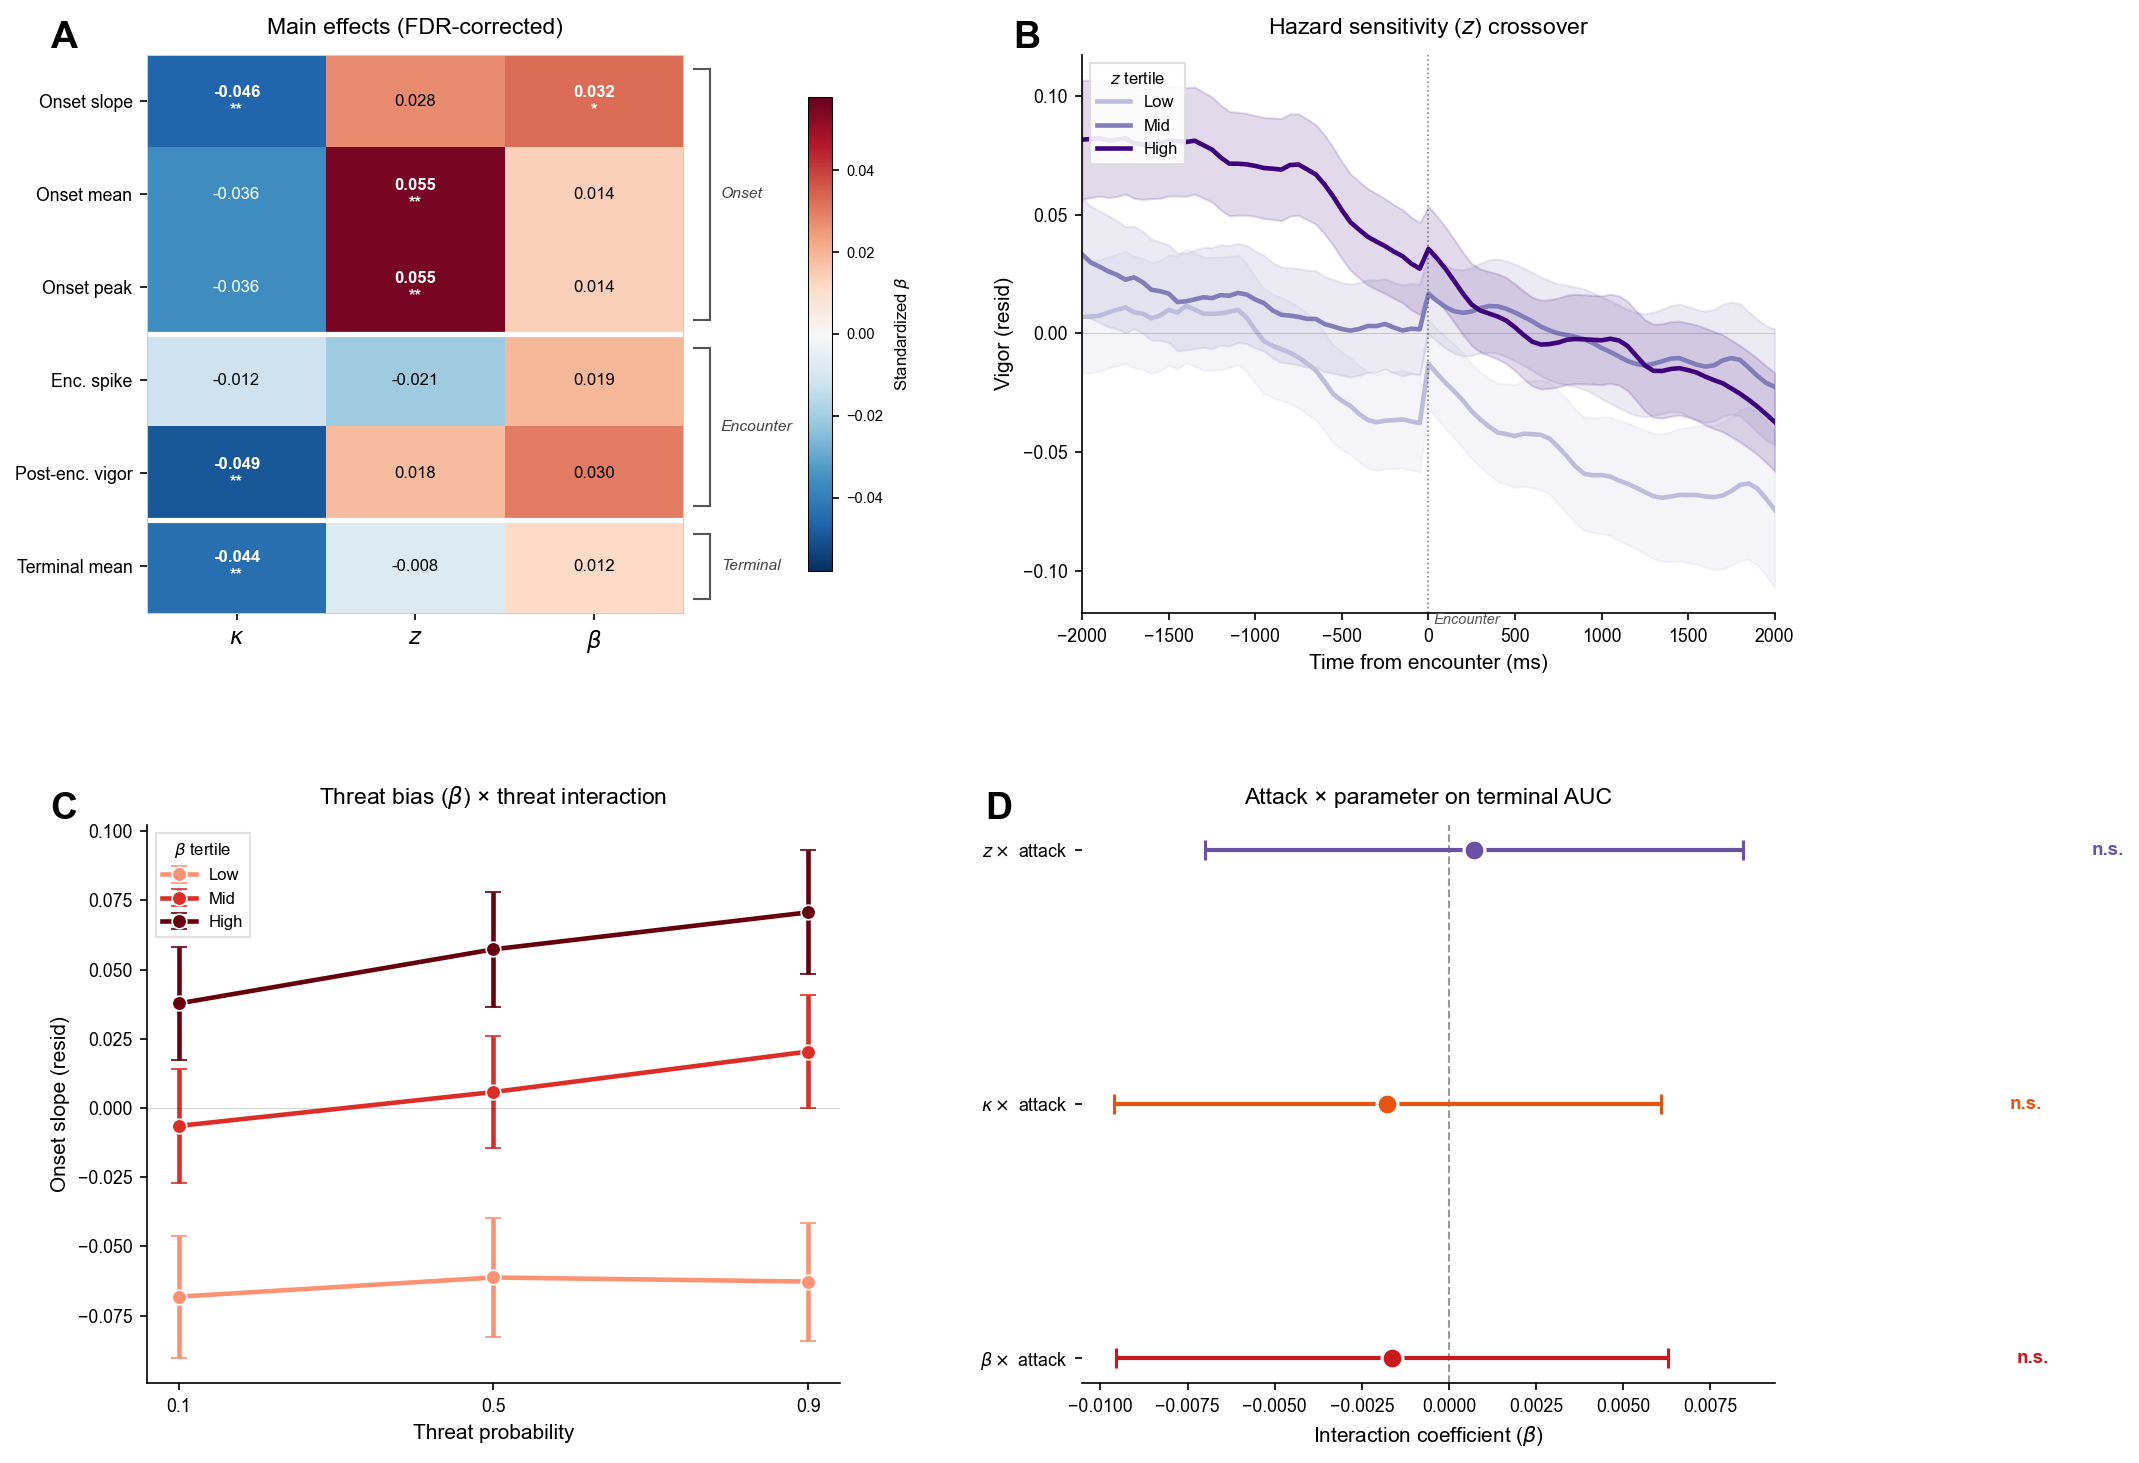

Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_dissociation_final.png
Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_dissociation_final.pdf


In [9]:
# ── Figure 2: Computational Parameter Dissociation (final clean) ──────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches


# Style constants
PANEL_FONT = 18
TITLE_FONT = 11
LABEL_FONT = 10
TICK_FONT  = 8.5

# Global style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
})

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def tertile_col(df, param, new_col):
    subj_param = df.groupby('subj')[param].first()
    cuts = subj_param.quantile([1/3, 2/3])
    def _assign(v):
        if v <= cuts.iloc[0]: return 'Low'
        elif v <= cuts.iloc[1]: return 'Mid'
        else: return 'High'
    mapping = subj_param.apply(_assign)
    df[new_col] = df['subj'].map(mapping)
    return df

def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt/2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results

# ─────────────────────────────────────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────────────────────────────────────

ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

tert_order = ['Low', 'Mid', 'High']

# Add z tertile to ts
if 'z_tert' not in ts.columns:
    subj_z = df_trial.groupby('subj')['z_z'].first().reset_index()
    cuts = subj_z['z_z'].quantile([1/3, 2/3])
    subj_z['z_tert'] = subj_z['z_z'].apply(
        lambda v: 'Low' if v <= cuts.iloc[0] else ('Mid' if v <= cuts.iloc[1] else 'High'))
    ts = ts.merge(subj_z[['subj', 'z_tert']], on='subj', how='left')

# Add beta tertile to df_trial
df_trial = tertile_col(df_trial, 'beta_z', 'beta_tert')

# Color palettes
tert_colors_z = {'Low': '#bcbddc', 'Mid': '#807dba', 'High': '#3f007d'}
tert_colors_beta = {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'}

param_colors_forest = {
    'z_z':     '#6a51a3',
    'kappa_z': '#e6550d',
    'beta_z':  '#cb181d',
}

# ─────────────────────────────────────────────────────────────────────────────
# Build figure
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11.5), dpi=150)
gs = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.35)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — Coefficient heatmap
# ═══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, 0])

heatmap_dvs = [
    'onset_slope', 'onset_mean', 'onset_peak',
    'encounter_spike', 'post_encounter_vigor',
    'terminal_mean',
]
heatmap_params = ['kappa_z', 'z_z', 'beta_z']
param_labels = ['$\\kappa$', '$z$', '$\\beta$']
dv_labels = [
    'Onset slope', 'Onset mean', 'Onset peak',
    'Enc. spike', 'Post-enc. vigor',
    'Terminal mean',
]

beta_matrix = np.zeros((len(heatmap_dvs), len(heatmap_params)))
sig_matrix = np.full((len(heatmap_dvs), len(heatmap_params)), '', dtype=object)

for i, dv in enumerate(heatmap_dvs):
    for j, param in enumerate(heatmap_params):
        row = fdr_df[(fdr_df['dv_base'] == dv) & (fdr_df['predictor'] == param)]
        if len(row) > 0:
            row = row.iloc[0]
            beta_matrix[i, j] = row['beta']
            if row['p_fdr'] < 0.001:
                sig_matrix[i, j] = '***'
            elif row['p_fdr'] < 0.01:
                sig_matrix[i, j] = '**'
            elif row['p_fdr'] < 0.05:
                sig_matrix[i, j] = '*'

vmax = np.max(np.abs(beta_matrix)) * 1.05
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax_a.imshow(beta_matrix, cmap='RdBu_r', norm=norm, aspect='auto')

for i in range(len(heatmap_dvs)):
    for j in range(len(heatmap_params)):
        val = beta_matrix[i, j]
        sig = sig_matrix[i, j]
        color = 'white' if abs(val) > vmax * 0.55 else 'black'
        txt = f'{val:.3f}' + (f'\n{sig}' if sig else '')
        ax_a.text(j, i, txt, ha='center', va='center',
                  fontsize=8, fontweight='bold' if sig else 'normal', color=color)

ax_a.set_xticks(range(len(heatmap_params)))
ax_a.set_xticklabels(param_labels, fontsize=LABEL_FONT + 1)
ax_a.set_yticks(range(len(heatmap_dvs)))
ax_a.set_yticklabels(dv_labels, fontsize=TICK_FONT)

for spine in ax_a.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('#ccc')

# Phase separators
ax_a.axhline(2.5, color='white', lw=2.5)
ax_a.axhline(4.5, color='white', lw=2.5)

# Phase brackets on the right (outside the heatmap)
phase_spans = [
    (0, 2, 'Onset'),
    (3, 4, 'Encounter'),
    (5, 5, 'Terminal'),
]

for y_start, y_end, label in phase_spans:
    y_mid = (y_start + y_end) / 2
    x_r = 1.02
    x_r2 = 1.05
    x_txt = 1.07
    # Vertical bracket
    ax_a.plot([x_r2, x_r2], [y_start - 0.35, y_end + 0.35],
              color='#555', lw=1, clip_on=False,
              transform=ax_a.get_yaxis_transform())
    # Horizontal ticks
    ax_a.plot([x_r, x_r2], [y_start - 0.35, y_start - 0.35],
              color='#555', lw=1, clip_on=False,
              transform=ax_a.get_yaxis_transform())
    ax_a.plot([x_r, x_r2], [y_end + 0.35, y_end + 0.35],
              color='#555', lw=1, clip_on=False,
              transform=ax_a.get_yaxis_transform())
    # Label
    ax_a.text(x_txt, y_mid, label, ha='left', va='center',
              fontsize=7.5, fontstyle='italic', color='#444',
              transform=ax_a.get_yaxis_transform())

cbar = fig.colorbar(im, ax=ax_a, fraction=0.046, pad=0.18, shrink=0.85)
cbar.set_label('Standardized $\\beta$', fontsize=8)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_linewidth(0.5)

ax_a.set_title('Main effects (FDR-corrected)', fontsize=TITLE_FONT, pad=10)
ax_a.text(-0.18, 1.06, 'A', transform=ax_a.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')
# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — z-tertile encounter-aligned PSTH
# ═══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[0, 1])

ts_enc = ts.dropna(subset=['encounterTime']).copy()
ts_enc['t_enc'] = ts_enc['t'] - ts_enc['encounterTime']
ts_enc_atk = ts_enc[ts_enc['isAttackTrial'] == True].copy()

t_grid_b, psth_b = group_psth(ts_enc_atk, 't_enc', 'vigor_resid', 'z_tert',
                               t_min=-2.0, t_max=2.0)

for tert in tert_order:
    if tert not in psth_b:
        continue
    m = psth_b[tert]['mean'].values
    s = psth_b[tert]['sem'].values
    t_ms = t_grid_b * 1000
    ax_b.plot(t_ms, m, color=tert_colors_z[tert], lw=2.2, label=f'{tert}')
    ax_b.fill_between(t_ms, m - s, m + s, color=tert_colors_z[tert], alpha=0.15)

ax_b.axvline(0, color='#333', ls=':', lw=0.8, alpha=0.6)
ax_b.axhline(0, color='k', lw=0.4, alpha=0.2)

# Encounter label
ax_b.text(30, ax_b.get_ylim()[0] if ax_b.get_ylim()[0] != 0 else -0.08,
          'Encounter', fontsize=7, color='#555', fontstyle='italic',
          va='top', ha='left')

ax_b.set_xlabel('Time from encounter (ms)', fontsize=LABEL_FONT)
ax_b.set_ylabel('Vigor (resid)', fontsize=LABEL_FONT)
ax_b.set_title('Hazard sensitivity ($z$) crossover', fontsize=TITLE_FONT, pad=10)
ax_b.legend(fontsize=8, loc='upper left', title='$z$ tertile', title_fontsize=8,
            framealpha=0.9, edgecolor='#ddd', fancybox=False)
ax_b.set_xlim(-2000, 2000)
ax_b.tick_params(labelsize=TICK_FONT)

ax_b.text(-0.10, 1.06, 'B', transform=ax_b.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL C — β × threat on onset slope
# ═══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[1, 0])

subj_means = (df_trial.groupby(['subj', 'threat', 'beta_tert'])['onset_slope_resid']
              .mean().reset_index())
grand = (subj_means.groupby(['threat', 'beta_tert'])['onset_slope_resid']
         .agg(['mean', 'sem']).reset_index())

for tert in tert_order:
    sub = grand[grand['beta_tert'] == tert]
    ax_c.errorbar(sub['threat'], sub['mean'], yerr=sub['sem'],
                  marker='o', ms=7, lw=2.2, capsize=4, capthick=1.5,
                  color=tert_colors_beta[tert], label=f'{tert}',
                  markeredgecolor='white', markeredgewidth=0.8)

ax_c.set_xlabel('Threat probability', fontsize=LABEL_FONT)
ax_c.set_ylabel('Onset slope (resid)', fontsize=LABEL_FONT)
ax_c.set_title('Threat bias ($\\beta$) × threat interaction', fontsize=TITLE_FONT, pad=10)
ax_c.set_xticks(sorted(df_trial['threat'].unique()))
ax_c.legend(fontsize=8, title='$\\beta$ tertile', title_fontsize=8,
            framealpha=0.9, edgecolor='#ddd', fancybox=False)
ax_c.tick_params(labelsize=TICK_FONT)
ax_c.axhline(0, color='k', lw=0.4, alpha=0.2)

ax_c.text(-0.14, 1.06, 'C', transform=ax_c.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL D — Forest plot: attack × parameter on terminal AUC
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 1])

interaction_params = ['attack_c:z_z', 'attack_c:kappa_z', 'attack_c:beta_z']
interaction_labels = [
    '$z \\times$ attack',
    '$\\kappa \\times$ attack',
    '$\\beta \\times$ attack',
]
forest_colors = [
    param_colors_forest['z_z'],
    param_colors_forest['kappa_z'],
    param_colors_forest['beta_z'],
]

y_positions = np.arange(len(interaction_params))

for i, (param, label, color) in enumerate(zip(interaction_params, interaction_labels, forest_colors)):
    row = fdr_df[(fdr_df['dv_base'] == 'terminal_auc') & (fdr_df['predictor'] == param)]
    if len(row) > 0:
        row = row.iloc[0]
        beta = row['beta']
        ci_lo = row['ci_lo']
        ci_hi = row['ci_hi']

        ax_d.errorbar(beta, i, xerr=[[beta - ci_lo], [ci_hi - beta]],
                      fmt='o', ms=10, color=color, capsize=5, capthick=2,
                      elinewidth=2, markeredgecolor='white', markeredgewidth=1.5,
                      zorder=3)

        if row['p_fdr'] < 0.001:
            sig_str = '***'
        elif row['p_fdr'] < 0.01:
            sig_str = '**'
        elif row['p_fdr'] < 0.05:
            sig_str = '*'
        else:
            sig_str = 'n.s.'

        ax_d.text(ci_hi + 0.01, i, sig_str, va='center', fontsize=9,
                  fontweight='bold', color=color)

ax_d.axvline(0, color='k', ls='--', lw=1, alpha=0.4, zorder=1)
ax_d.set_yticks(y_positions)
ax_d.set_yticklabels(interaction_labels, fontsize=LABEL_FONT)
ax_d.set_xlabel('Interaction coefficient ($\\beta$)', fontsize=LABEL_FONT)
ax_d.set_title('Attack × parameter on terminal AUC', fontsize=TITLE_FONT, pad=10)
ax_d.tick_params(labelsize=TICK_FONT)
ax_d.invert_yaxis()
ax_d.axhline(0, color='k', lw=0, alpha=0)  # placeholder

# Restore left spine only for forest plot
ax_d.spines['left'].set_visible(False)

ax_d.text(-0.14, 1.06, 'D', transform=ax_d.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Save ──
fig.savefig(FIGS_DIR / 'fig2_parameter_dissociation_final.png', dpi=300,
            bbox_inches='tight', facecolor='white')
fig.savefig(FIGS_DIR / 'fig2_parameter_dissociation_final.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGS_DIR / "fig2_parameter_dissociation_final.png"}')
print(f'Saved → {FIGS_DIR / "fig2_parameter_dissociation_final.pdf"}')

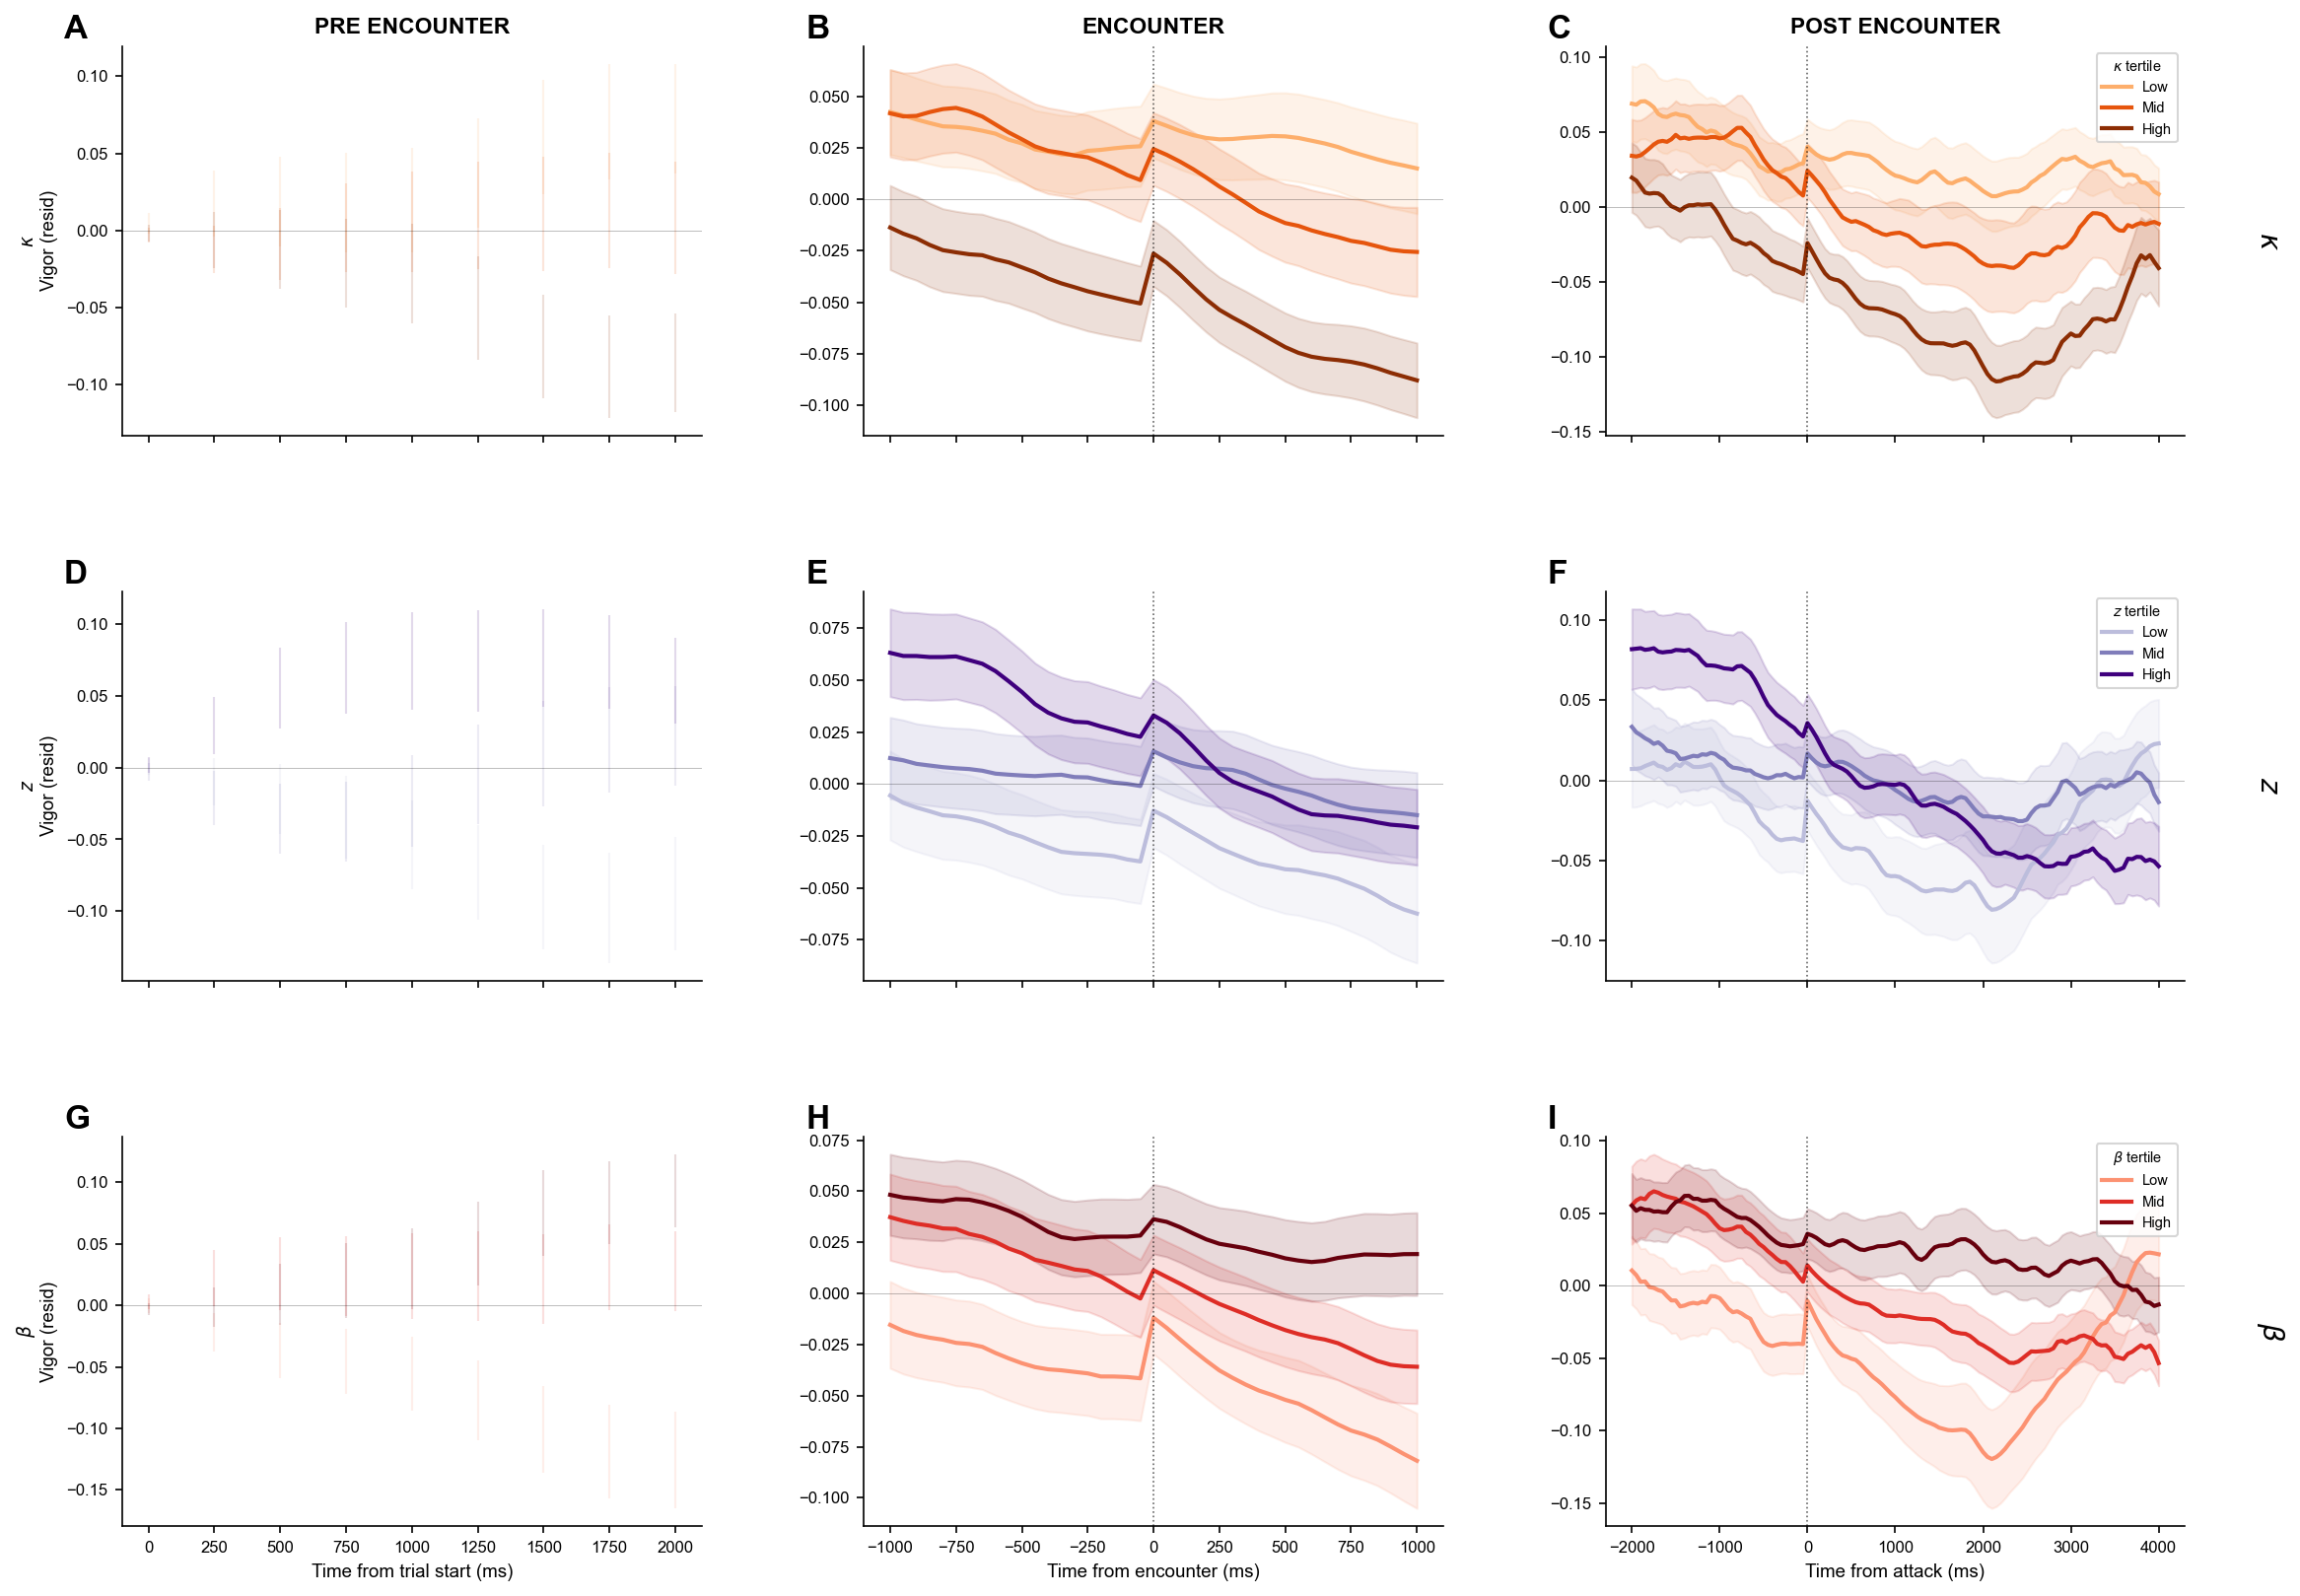

Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_phase_timeseries.png


In [10]:
# ── Figure 2: Parameter × Phase Time Series (3×3 grid) ───────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# Style constants
PANEL_FONT = 16
TITLE_FONT = 11
LABEL_FONT = 9
TICK_FONT  = 8

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def tertile_col(df, param, new_col):
    subj_param = df.groupby('subj')[param].first()
    cuts = subj_param.quantile([1/3, 2/3])
    def _assign(v):
        if v <= cuts.iloc[0]: return 'Low'
        elif v <= cuts.iloc[1]: return 'Mid'
        else: return 'High'
    mapping = subj_param.apply(_assign)
    df[new_col] = df['subj'].map(mapping)
    return df

def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt/2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results

# ─────────────────────────────────────────────────────────────────────────────
# Load and prepare time series
# ─────────────────────────────────────────────────────────────────────────────
ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

# Parameters and color palettes
params = ['kappa_z', 'z_z', 'beta_z']
param_display = {'kappa_z': '$\\kappa$', 'z_z': '$z$', 'beta_z': '$\\beta$'}

# Orange for kappa, purple for z, red for beta
param_colors = {
    'kappa_z': {'Low': '#fdae6b', 'Mid': '#e6550d', 'High': '#8c2d04'},
    'z_z':     {'Low': '#bcbddc', 'Mid': '#807dba', 'High': '#3f007d'},
    'beta_z':  {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'},
}

tert_order = ['Low', 'Mid', 'High']

# Add tertile columns for each parameter
for param in params:
    tert_col_name = f'{param}_tert'
    if tert_col_name not in ts.columns:
        # Merge from df_trial
        subj_p = df_trial.groupby('subj')[param].first().reset_index()
        cuts = subj_p[param].quantile([1/3, 2/3])
        subj_p[tert_col_name] = subj_p[param].apply(
            lambda v: 'Low' if v <= cuts.iloc[0] else ('Mid' if v <= cuts.iloc[1] else 'High'))
        ts = ts.merge(subj_p[['subj', tert_col_name]], on='subj', how='left')

# Prepare aligned time columns
# Onset: relative to trial start (t already in seconds from trial start)
# Encounter: relative to encounter time
# Terminal: relative to attack start (for attack trials)

ts_onset = ts.copy()
ts_onset['t_onset'] = ts_onset['t']  # already relative to trial start

ts_enc = ts.dropna(subset=['encounterTime']).copy()
ts_enc['t_enc'] = ts_enc['t'] - ts_enc['encounterTime']

ts_term = ts[ts['isAttackTrial'] == True].copy()
if 'attackTime' in ts_term.columns:
    ts_term = ts_term.dropna(subset=['attackTime'])
    ts_term['t_atk'] = ts_term['t'] - ts_term['attackTime']
elif 'encounterTime' in ts_term.columns:
    # Fall back: use encounter time as anchor for terminal
    ts_term = ts_term.dropna(subset=['encounterTime'])
    ts_term['t_atk'] = ts_term['t'] - ts_term['encounterTime']

# ─────────────────────────────────────────────────────────────────────────────
# Phase definitions: (dataframe, time_col, t_min, t_max, title, xlabel)
# ─────────────────────────────────────────────────────────────────────────────
phases = [
    (ts_onset, 't_onset', 0.0, 2.0, 'PRE ENCOUNTER', 'Time from trial start (ms)'),
    (ts_enc,   't_enc',  -1.0, 1.0, 'ENCOUNTER', 'Time from encounter (ms)'),
    (ts_term,  't_atk',  -2.0, 4.0, 'POST ENCOUNTER', 'Time from attack (ms)'),
]

# ─────────────────────────────────────────────────────────────────────────────
# Build figure: 3 rows (params) × 3 cols (phases)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 13), dpi=150)
fig.subplots_adjust(hspace=0.40, wspace=0.28)

for row_i, param in enumerate(params):
    tert_col_name = f'{param}_tert'
    colors = param_colors[param]

    for col_i, (df_phase, t_col, t_min, t_max, phase_title, xlabel) in enumerate(phases):
        ax = axes[row_i, col_i]

        t_grid, psth = group_psth(df_phase, t_col, 'vigor_resid', tert_col_name,
                                   t_min=t_min, t_max=t_max)

        for tert in tert_order:
            if tert not in psth:
                continue
            m = psth[tert]['mean'].values
            s = psth[tert]['sem'].values
            t_ms = t_grid * 1000

            ax.plot(t_ms, m, color=colors[tert], lw=2, label=f'{tert}')
            ax.fill_between(t_ms, m - s, m + s, color=colors[tert], alpha=0.15)

        # Event marker
        if col_i == 0:
            pass  # No specific event line for onset
        elif col_i == 1:
            ax.axvline(0, color='k', ls=':', lw=0.8, alpha=0.6)
        elif col_i == 2:
            ax.axvline(0, color='k', ls=':', lw=0.8, alpha=0.6)

        ax.axhline(0, color='k', lw=0.4, alpha=0.3)
        ax.tick_params(labelsize=TICK_FONT)

        # Column titles (top row only)
        if row_i == 0:
            ax.set_title(phase_title, fontsize=TITLE_FONT, fontweight='bold')

        # X labels (bottom row only)
        if row_i == 2:
            ax.set_xlabel(xlabel, fontsize=LABEL_FONT)
        else:
            ax.set_xticklabels([])

        # Y labels (left column only)
        if col_i == 0:
            ax.set_ylabel(f'{param_display[param]}\nVigor (resid)', fontsize=LABEL_FONT)

        # Legend (rightmost column only)
        if col_i == 2:
            ax.legend(fontsize=7, title=f'{param_display[param]} tertile',
                      title_fontsize=7, loc='upper right')

# ── Row labels on the right side ──
for row_i, param in enumerate(params):
    axes[row_i, 2].text(1.12, 0.5, param_display[param],
                         transform=axes[row_i, 2].transAxes,
                         fontsize=14, fontweight='bold', va='center',
                         rotation=-90)

# ── Panel labels ──
panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
for idx, (row_i, col_i) in enumerate([(r, c) for r in range(3) for c in range(3)]):
    axes[row_i, col_i].text(-0.10, 1.08, panel_labels[idx],
                             transform=axes[row_i, col_i].transAxes,
                             fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Save ──
fig.savefig(FIGS_DIR / 'fig2_parameter_phase_timeseries.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGS_DIR / "fig2_parameter_phase_timeseries.png"}')

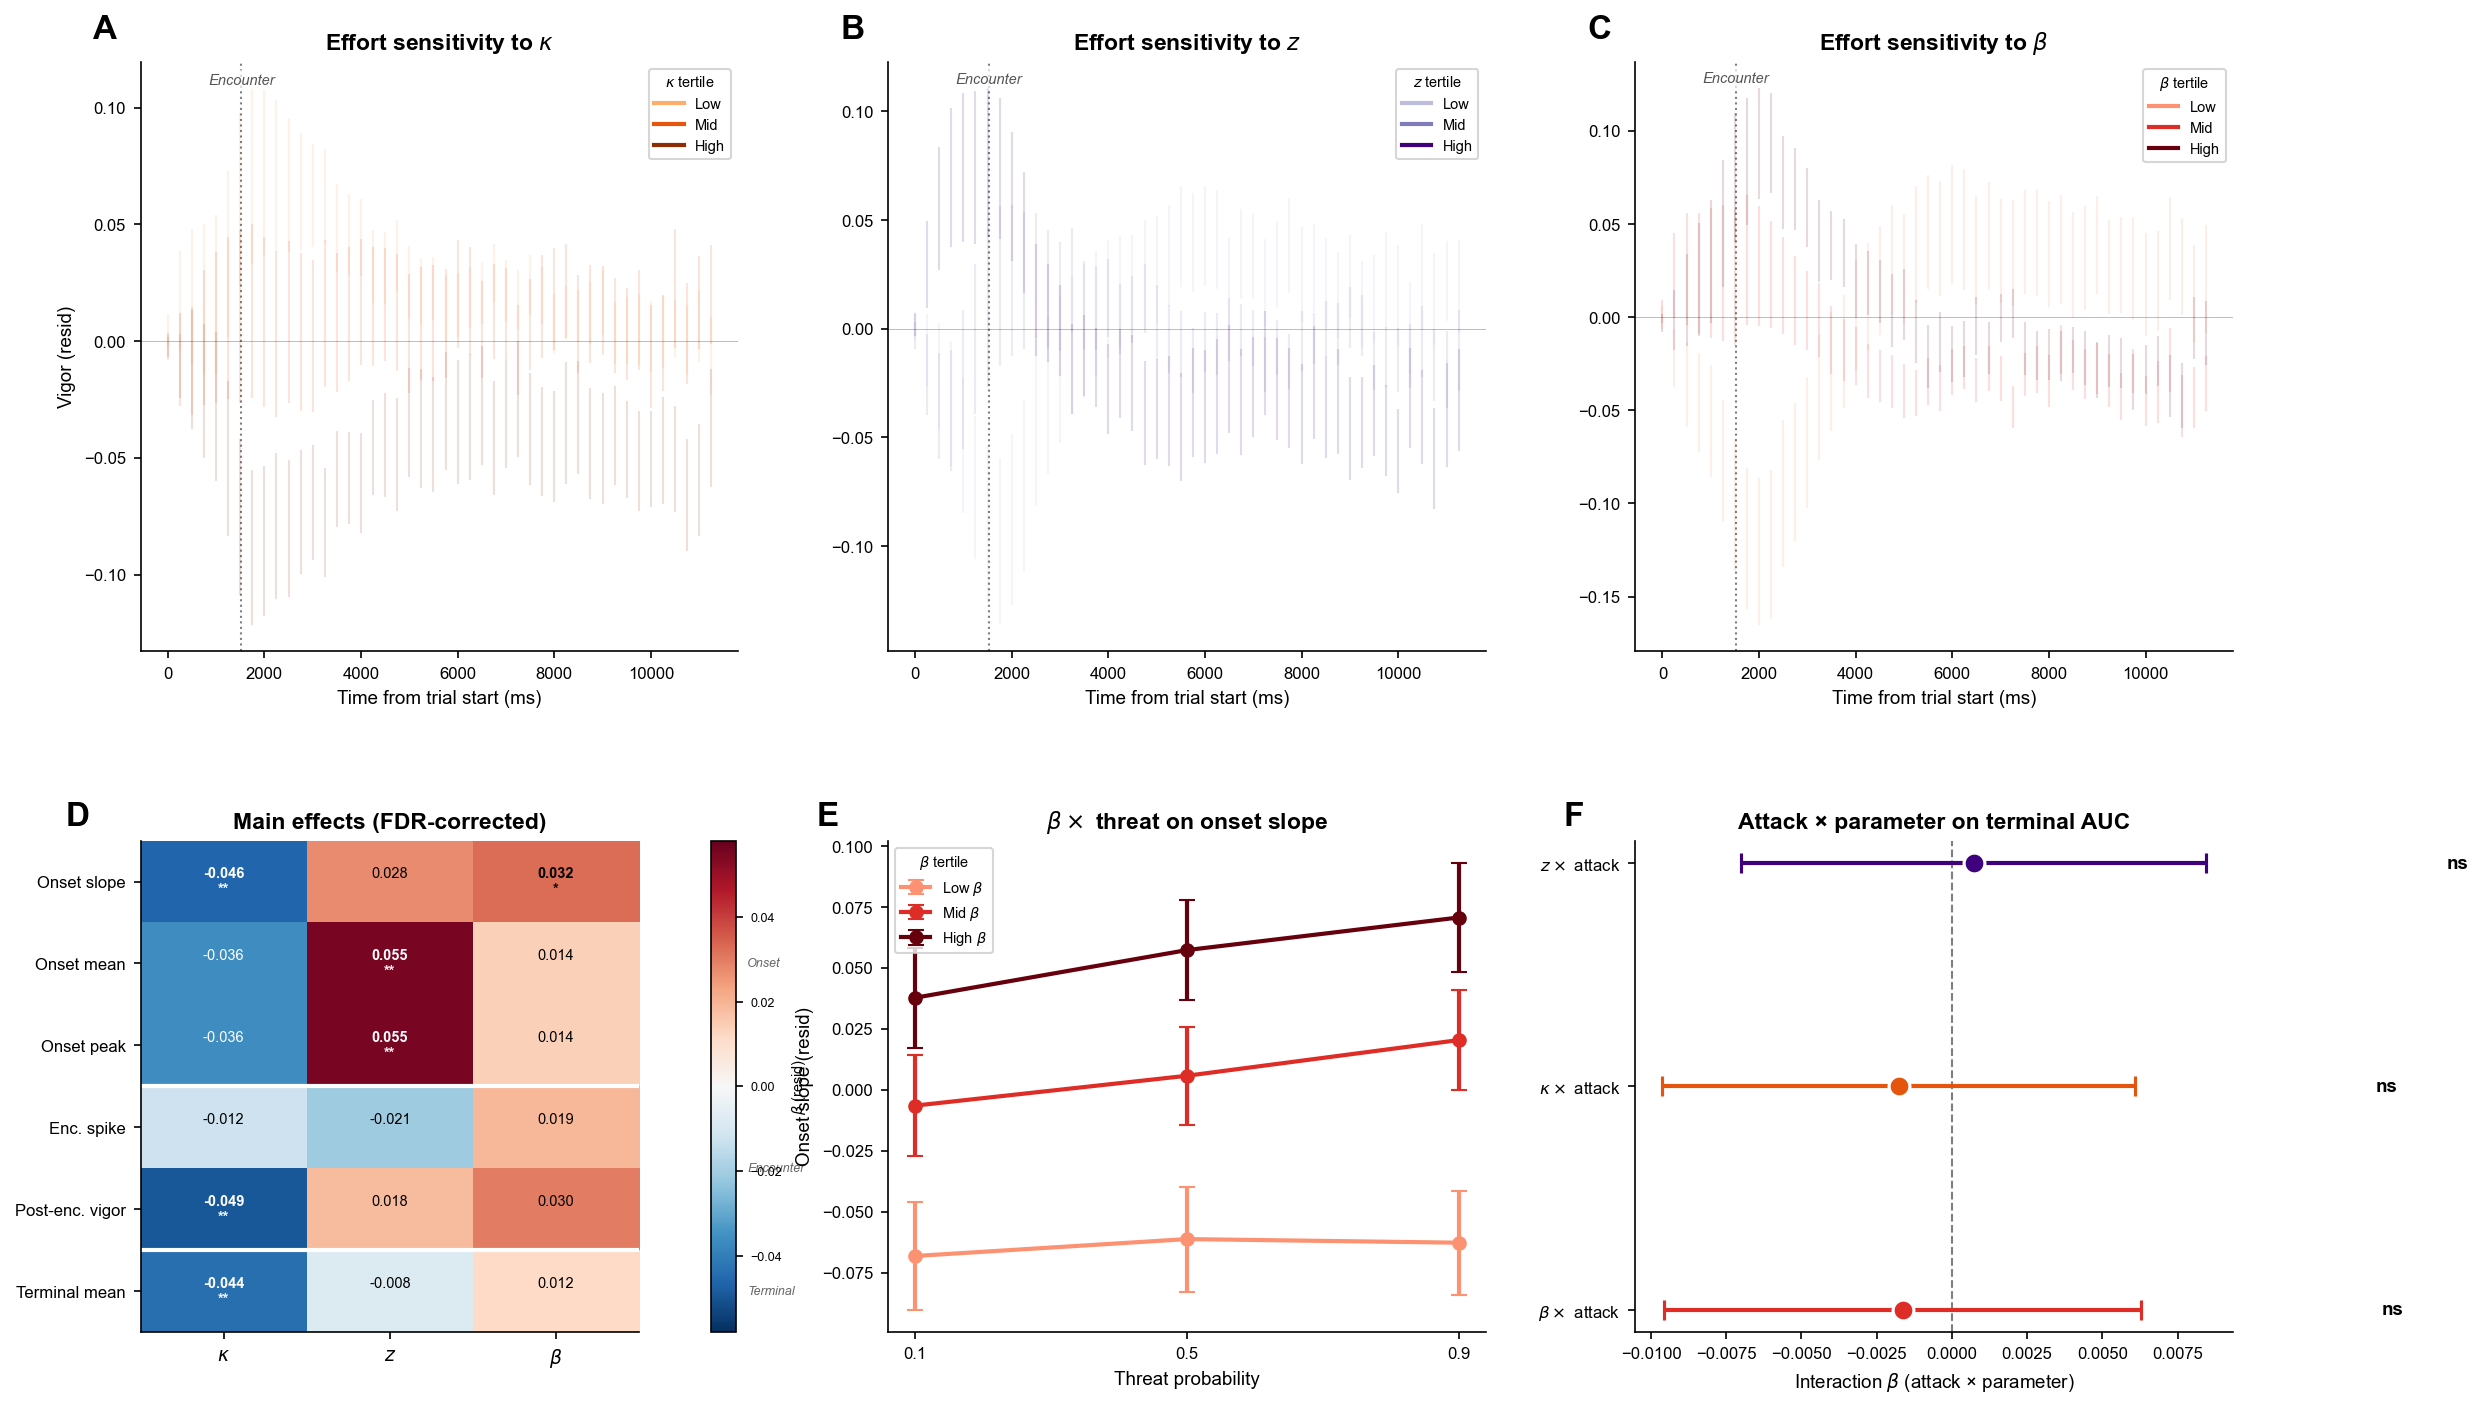

Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_dissociation_wide.png


In [11]:
# ── Figure 2: Computational Parameter Dissociation (wide layout) ──────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patches as mpatches


# Style constants
PANEL_FONT = 16
TITLE_FONT = 11
LABEL_FONT = 9
TICK_FONT  = 8

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def tertile_col(df, param, new_col):
    subj_param = df.groupby('subj')[param].first()
    cuts = subj_param.quantile([1/3, 2/3])
    def _assign(v):
        if v <= cuts.iloc[0]: return 'Low'
        elif v <= cuts.iloc[1]: return 'Mid'
        else: return 'High'
    mapping = subj_param.apply(_assign)
    df[new_col] = df['subj'].map(mapping)
    return df

def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt/2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results

# ─────────────────────────────────────────────────────────────────────────────
# Prepare time series data
# ─────────────────────────────────────────────────────────────────────────────
ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

params = ['kappa_z', 'z_z', 'beta_z']
param_display = {'kappa_z': '$\\kappa$', 'z_z': '$z$', 'beta_z': '$\\beta$'}
tert_order = ['Low', 'Mid', 'High']

# Color palettes: light→dark = Low→High
param_colors = {
    'kappa_z': {'Low': '#fdae6b', 'Mid': '#e6550d', 'High': '#8c2d04'},
    'z_z':     {'Low': '#bcbddc', 'Mid': '#807dba', 'High': '#3f007d'},
    'beta_z':  {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'},
}

# Add tertile columns to ts
for param in params:
    tert_col_name = f'{param}_tert'
    if tert_col_name not in ts.columns:
        subj_p = df_trial.groupby('subj')[param].first().reset_index()
        cuts = subj_p[param].quantile([1/3, 2/3])
        subj_p[tert_col_name] = subj_p[param].apply(
            lambda v: 'Low' if v <= cuts.iloc[0] else ('Mid' if v <= cuts.iloc[1] else 'High'))
        ts = ts.merge(subj_p[['subj', tert_col_name]], on='subj', how='left')

# Add tertile columns to df_trial for Panel E
df_trial = tertile_col(df_trial, 'beta_z', 'beta_tert')

# ─────────────────────────────────────────────────────────────────────────────
# For the full-trial time series, we use trial-start-aligned time (t)
# and mark encounter and attack times as vertical bands/lines
# ─────────────────────────────────────────────────────────────────────────────

# Compute median event times for annotation
median_encounter = df_trial['encounterTime'].median()
median_attack = df_trial.loc[df_trial['isAttackTrial'] == True, 'attackTime'].median() \
    if 'attackTime' in df_trial.columns else None

# Full trial range
T_MIN = 0.0
T_MAX = ts['t'].quantile(0.95)  # avoid sparse tail

# ─────────────────────────────────────────────────────────────────────────────
# Build figure: top row = 3 time series, bottom row = 3 panels
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11), dpi=150)
gs = gridspec.GridSpec(2, 3, height_ratios=[1.2, 1], hspace=0.35, wspace=0.25)

# ═══════════════════════════════════════════════════════════════════════════════
# TOP ROW: Full-trial time series, one per parameter
# ═══════════════════════════════════════════════════════════════════════════════

for col_i, param in enumerate(params):
    ax = fig.add_subplot(gs[0, col_i])
    tert_col_name = f'{param}_tert'
    colors = param_colors[param]

    t_grid, psth = group_psth(ts, 't', 'vigor_resid', tert_col_name,
                               t_min=T_MIN, t_max=T_MAX)

    for tert in tert_order:
        if tert not in psth:
            continue
        m = psth[tert]['mean'].values
        s = psth[tert]['sem'].values
        t_ms = t_grid * 1000

        ax.plot(t_ms, m, color=colors[tert], lw=2, label=f'{tert}')
        ax.fill_between(t_ms, m - s, m + s, color=colors[tert], alpha=0.15)

    # Phase boundary markers
    if median_encounter is not None:
        enc_ms = median_encounter * 1000
        ax.axvline(enc_ms, color='k', ls=':', lw=1, alpha=0.5)
        ax.text(enc_ms, ax.get_ylim()[1] * 0.92, 'Encounter', fontsize=7,
                ha='center', fontstyle='italic', color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

    if median_attack is not None:
        atk_ms = median_attack * 1000
        ax.axvline(atk_ms, color='k', ls=':', lw=1, alpha=0.5)
        ax.text(atk_ms, ax.get_ylim()[1] * 0.78, 'Attack', fontsize=7,
                ha='center', fontstyle='italic', color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

    # Phase shading
    ax.axhline(0, color='k', lw=0.4, alpha=0.3)

    ax.set_title(f'Effort sensitivity to {param_display[param]}', fontsize=TITLE_FONT,
                 fontweight='bold')
    ax.set_xlabel('Time from trial start (ms)', fontsize=LABEL_FONT)
    ax.tick_params(labelsize=TICK_FONT)

    if col_i == 0:
        ax.set_ylabel('Vigor (resid)', fontsize=LABEL_FONT)

    ax.legend(fontsize=7, title=f'{param_display[param]} tertile',
              title_fontsize=7, loc='best')

    # Panel label
    label = ['A', 'B', 'C'][col_i]
    ax.text(-0.08, 1.08, label, transform=ax.transAxes,
            fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM LEFT (D): Coefficient heatmap
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 0])

heatmap_dvs = [
    'onset_slope', 'onset_mean', 'onset_peak',
    'encounter_spike', 'post_encounter_vigor',
    'terminal_mean',
]
heatmap_params = ['kappa_z', 'z_z', 'beta_z']
param_labels_hm = ['$\\kappa$', '$z$', '$\\beta$']
dv_labels = [
    'Onset slope', 'Onset mean', 'Onset peak',
    'Enc. spike', 'Post-enc. vigor',
    'Terminal mean',
]

beta_matrix = np.zeros((len(heatmap_dvs), len(heatmap_params)))
sig_matrix = np.full((len(heatmap_dvs), len(heatmap_params)), '', dtype=object)

for i, dv in enumerate(heatmap_dvs):
    for j, param in enumerate(heatmap_params):
        row = fdr_df[(fdr_df['dv_base'] == dv) & (fdr_df['predictor'] == param)]
        if len(row) > 0:
            row = row.iloc[0]
            beta_matrix[i, j] = row['beta']
            if row['p_fdr'] < 0.001:
                sig_matrix[i, j] = '***'
            elif row['p_fdr'] < 0.01:
                sig_matrix[i, j] = '**'
            elif row['p_fdr'] < 0.05:
                sig_matrix[i, j] = '*'

vmax = np.max(np.abs(beta_matrix)) * 1.05
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

im = ax_d.imshow(beta_matrix, cmap='RdBu_r', norm=norm, aspect='auto')

for i in range(len(heatmap_dvs)):
    for j in range(len(heatmap_params)):
        val = beta_matrix[i, j]
        sig = sig_matrix[i, j]
        color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax_d.text(j, i, f'{val:.3f}\n{sig}', ha='center', va='center',
                  fontsize=7, fontweight='bold' if sig else 'normal', color=color)

ax_d.set_xticks(range(len(heatmap_params)))
ax_d.set_xticklabels(param_labels_hm, fontsize=LABEL_FONT)
ax_d.set_yticks(range(len(heatmap_dvs)))
ax_d.set_yticklabels(dv_labels, fontsize=TICK_FONT)
ax_d.set_title('Main effects (FDR-corrected)', fontsize=TITLE_FONT, fontweight='bold')

ax_d.axhline(2.5, color='white', lw=2)
ax_d.axhline(4.5, color='white', lw=2)

for y_center, label in [(1, 'Onset'), (3.5, 'Encounter'), (5, 'Terminal')]:
    ax_d.text(len(heatmap_params) + 0.15, y_center, label, va='center',
              fontsize=6, fontstyle='italic', color='#666')

cbar = fig.colorbar(im, ax=ax_d, fraction=0.046, pad=0.12)
cbar.set_label('$\\beta$ (resid)', fontsize=7)
cbar.ax.tick_params(labelsize=6)

ax_d.text(-0.15, 1.08, 'D', transform=ax_d.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM CENTER (E): β × threat on onset slope
# ═══════════════════════════════════════════════════════════════════════════════
ax_e = fig.add_subplot(gs[1, 1])

subj_means = (df_trial.groupby(['subj', 'threat', 'beta_tert'])['onset_slope_resid']
              .mean().reset_index())
grand = (subj_means.groupby(['threat', 'beta_tert'])['onset_slope_resid']
         .agg(['mean', 'sem']).reset_index())

tert_colors_beta = {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'}

for tert in tert_order:
    sub = grand[grand['beta_tert'] == tert]
    ax_e.errorbar(sub['threat'], sub['mean'], yerr=sub['sem'],
                  marker='o', ms=6, lw=2, capsize=4,
                  color=tert_colors_beta[tert], label=f'{tert} $\\beta$')

ax_e.set_xlabel('Threat probability', fontsize=LABEL_FONT)
ax_e.set_ylabel('Onset slope (resid)', fontsize=LABEL_FONT)
ax_e.set_title('$\\beta \\times$ threat on onset slope', fontsize=TITLE_FONT, fontweight='bold')
ax_e.set_xticks(sorted(df_trial['threat'].unique()))
ax_e.legend(fontsize=7, title='$\\beta$ tertile', title_fontsize=7)
ax_e.tick_params(labelsize=TICK_FONT)

ax_e.text(-0.12, 1.08, 'E', transform=ax_e.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# BOTTOM RIGHT (F): Forest plot — attack × parameter on terminal AUC
# ═══════════════════════════════════════════════════════════════════════════════
ax_f = fig.add_subplot(gs[1, 2])

interaction_params = ['attack_c:z_z', 'attack_c:kappa_z', 'attack_c:beta_z']
interaction_labels = ['$z \\times$ attack', '$\\kappa \\times$ attack', '$\\beta \\times$ attack']
forest_colors = ['#3f007d', '#e6550d', '#de2d26']

y_positions = np.arange(len(interaction_params))

for i, (param, label, color) in enumerate(zip(interaction_params, interaction_labels, forest_colors)):
    row = fdr_df[(fdr_df['dv_base'] == 'terminal_auc') & (fdr_df['predictor'] == param)]
    if len(row) > 0:
        row = row.iloc[0]
        beta = row['beta']
        ci_lo = row['ci_lo']
        ci_hi = row['ci_hi']

        ax_f.errorbar(beta, i, xerr=[[beta - ci_lo], [ci_hi - beta]],
                      fmt='o', ms=10, color=color, capsize=5, capthick=2,
                      elinewidth=2, markeredgecolor='white', markeredgewidth=1.5,
                      zorder=3)

        if row['p_fdr'] < 0.001:
            sig_str = '***'
        elif row['p_fdr'] < 0.01:
            sig_str = '**'
        elif row['p_fdr'] < 0.05:
            sig_str = '*'
        else:
            sig_str = 'ns'

        ax_f.text(ci_hi + 0.008, i, sig_str, va='center', fontsize=9, fontweight='bold')

ax_f.axvline(0, color='k', ls='--', lw=1, alpha=0.5, zorder=1)
ax_f.set_yticks(y_positions)
ax_f.set_yticklabels(interaction_labels, fontsize=LABEL_FONT)
ax_f.set_xlabel('Interaction $\\beta$ (attack × parameter)', fontsize=LABEL_FONT)
ax_f.set_title('Attack × parameter on terminal AUC', fontsize=TITLE_FONT, fontweight='bold')
ax_f.tick_params(labelsize=TICK_FONT)
ax_f.invert_yaxis()

ax_f.text(-0.12, 1.08, 'F', transform=ax_f.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Save ──
fig.savefig(FIGS_DIR / 'fig2_parameter_dissociation_wide.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGS_DIR / "fig2_parameter_dissociation_wide.png"}')

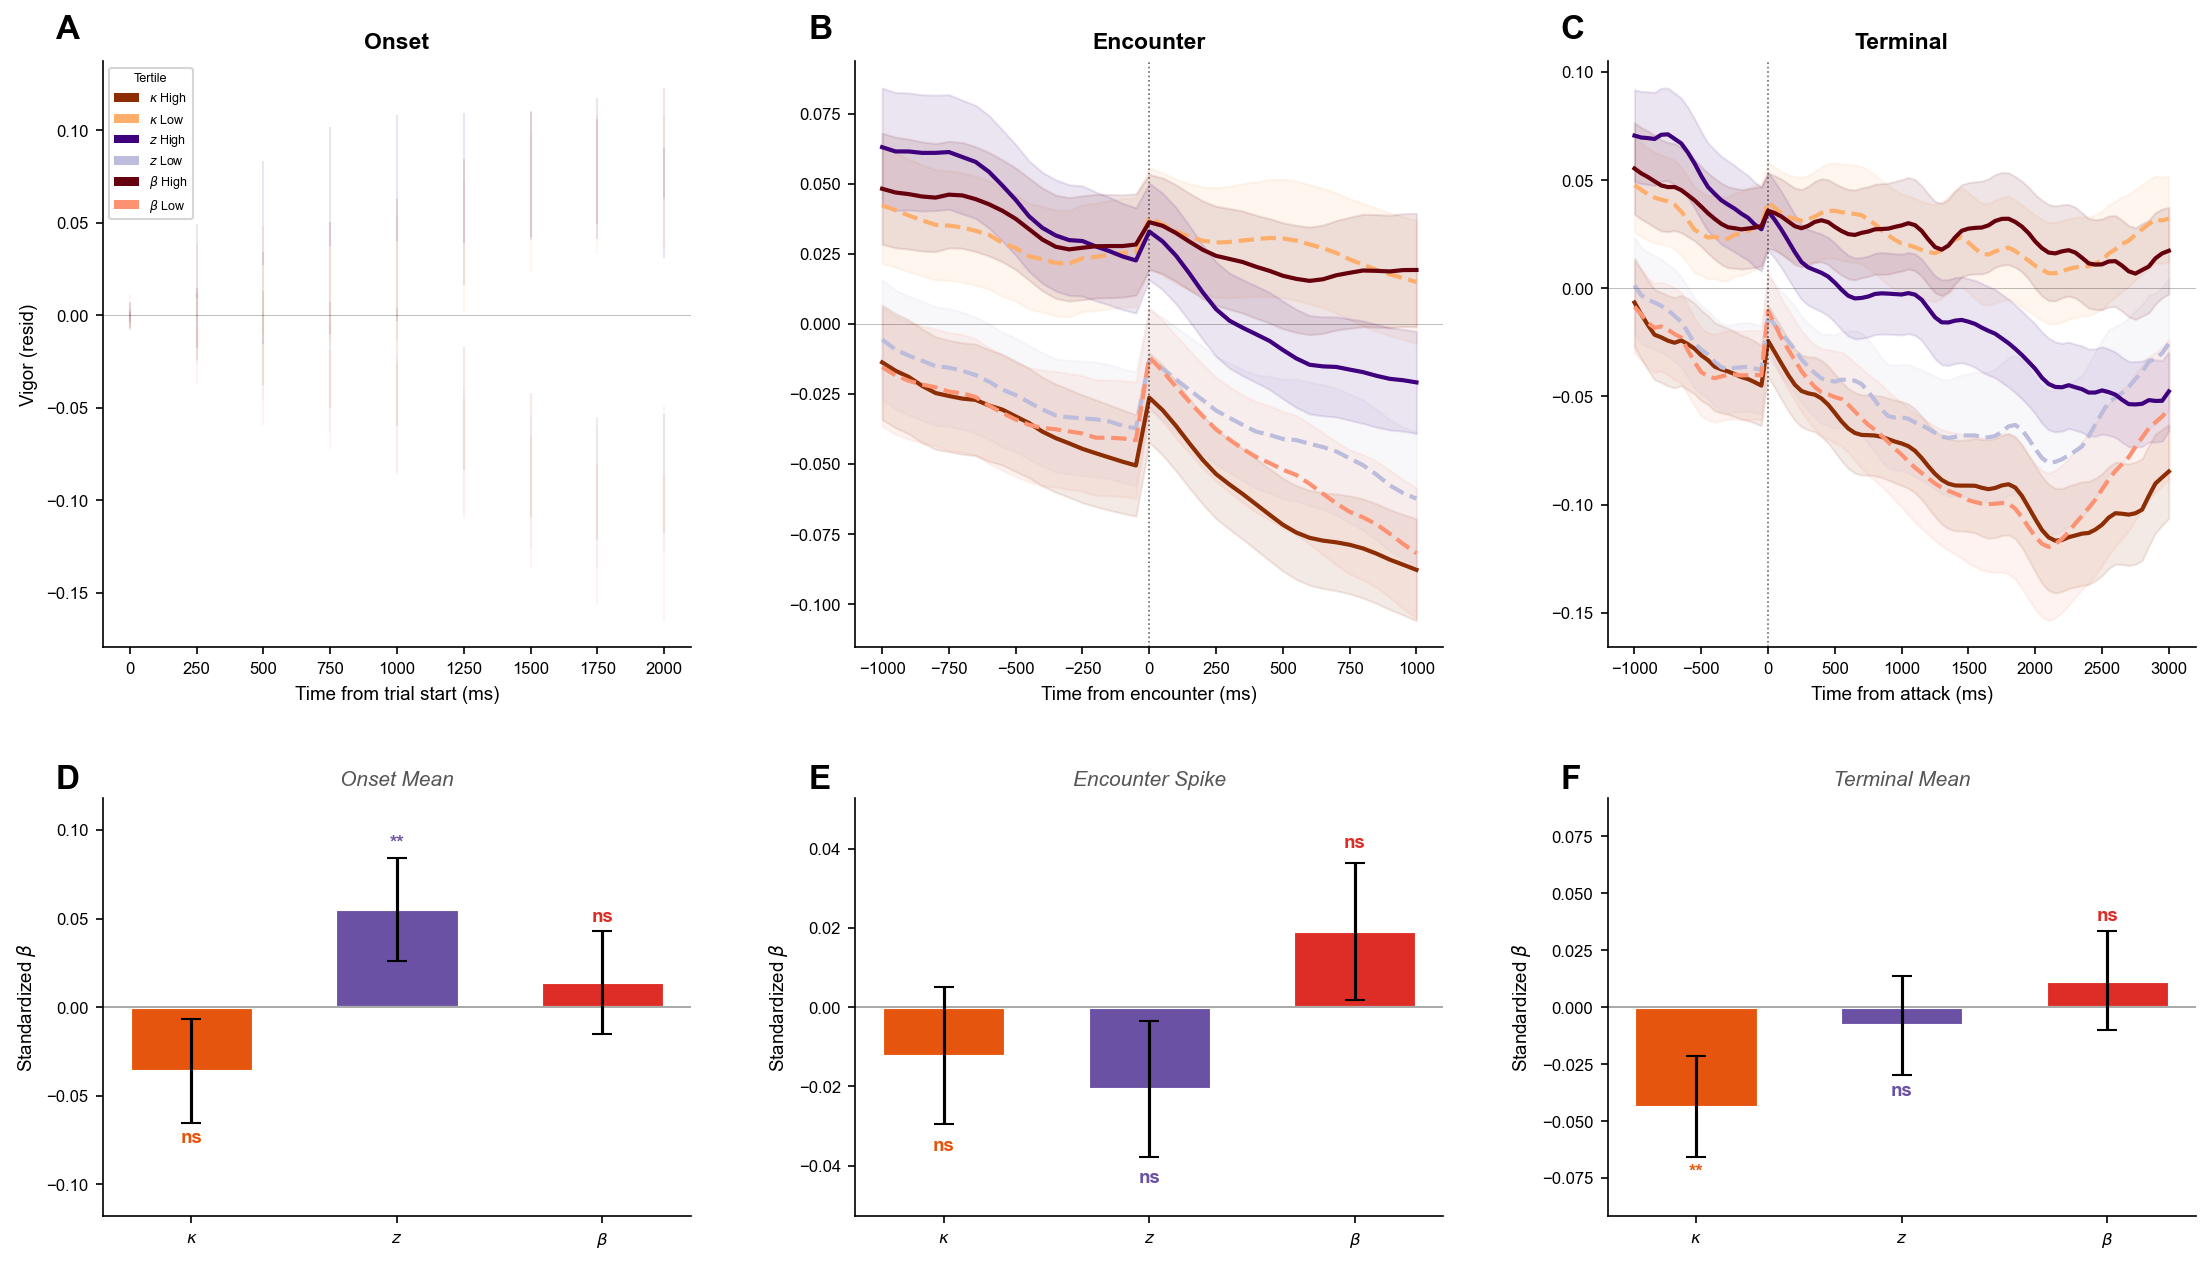

Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_dissociation_v4.png


In [12]:
# ── Figure 2: Time series + bar charts by phase ──────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches


# Style constants
PANEL_FONT = 16
TITLE_FONT = 11
LABEL_FONT = 9
TICK_FONT  = 8

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def tertile_col(df, param, new_col):
    subj_param = df.groupby('subj')[param].first()
    cuts = subj_param.quantile([1/3, 2/3])
    def _assign(v):
        if v <= cuts.iloc[0]: return 'Low'
        elif v <= cuts.iloc[1]: return 'Mid'
        else: return 'High'
    mapping = subj_param.apply(_assign)
    df[new_col] = df['subj'].map(mapping)
    return df

def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt/2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results

# ─────────────────────────────────────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────────────────────────────────────
ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

params = ['kappa_z', 'z_z', 'beta_z']
param_display = {'kappa_z': '$\\kappa$', 'z_z': '$z$', 'beta_z': '$\\beta$'}
param_colors = {
    'kappa_z': '#e6550d',
    'z_z':     '#6a51a3',
    'beta_z':  '#de2d26',
}
tert_order = ['Low', 'Mid', 'High']

# Tertile colors per parameter (light → dark)
param_tert_colors = {
    'kappa_z': {'Low': '#fdae6b', 'Mid': '#e6550d', 'High': '#8c2d04'},
    'z_z':     {'Low': '#bcbddc', 'Mid': '#807dba', 'High': '#3f007d'},
    'beta_z':  {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'},
}

# Add tertiles to ts
for param in params:
    tert_col_name = f'{param}_tert'
    if tert_col_name not in ts.columns:
        subj_p = df_trial.groupby('subj')[param].first().reset_index()
        cuts = subj_p[param].quantile([1/3, 2/3])
        subj_p[tert_col_name] = subj_p[param].apply(
            lambda v: 'Low' if v <= cuts.iloc[0] else ('Mid' if v <= cuts.iloc[1] else 'High'))
        ts = ts.merge(subj_p[['subj', tert_col_name]], on='subj', how='left')

# Prepare phase-aligned dataframes
ts_onset = ts.copy()
ts_onset['t_onset'] = ts_onset['t']

ts_enc = ts.dropna(subset=['encounterTime']).copy()
ts_enc['t_enc'] = ts_enc['t'] - ts_enc['encounterTime']

ts_term = ts[ts['isAttackTrial'] == True].copy()
if 'attackTime' in ts_term.columns:
    ts_term = ts_term.dropna(subset=['attackTime'])
    ts_term['t_atk'] = ts_term['t'] - ts_term['attackTime']
else:
    ts_term = ts_term.dropna(subset=['encounterTime'])
    ts_term['t_atk'] = ts_term['t'] - ts_term['encounterTime']

# ─────────────────────────────────────────────────────────────────────────────
# Phase definitions
# ─────────────────────────────────────────────────────────────────────────────

# (df, time_col, t_min, t_max, title, xlabel, dv_base for bar, event_line_at)
phase_defs = [
    (ts_onset, 't_onset', 0.0, 2.0,
     'Onset', 'Time from trial start (ms)', 'onset_mean', None),
    (ts_enc,   't_enc',  -1.0, 1.0,
     'Encounter', 'Time from encounter (ms)', 'encounter_spike', 0),
    (ts_term,  't_atk',  -1.0, 3.0,
     'Terminal', 'Time from attack (ms)', 'terminal_mean', 0),
]

# ─────────────────────────────────────────────────────────────────────────────
# Build figure: 2 rows × 3 cols (top = time series, bottom = bar charts)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10), dpi=150)
gs = gridspec.GridSpec(2, 3, height_ratios=[1.4, 1], hspace=0.30, wspace=0.28)

panel_labels_top = ['A', 'B', 'C']
panel_labels_bot = ['D', 'E', 'F']

for col_i, (df_phase, t_col, t_min, t_max, phase_title, xlabel, dv_base, event_t) in enumerate(phase_defs):

    # ── TOP ROW: Time series with all 3 parameters overlaid ──────────────
    ax_ts = fig.add_subplot(gs[0, col_i])

    for param in params:
        tert_col_name = f'{param}_tert'
        colors = param_tert_colors[param]

        t_grid, psth = group_psth(df_phase, t_col, 'vigor_resid', tert_col_name,
                                   t_min=t_min, t_max=t_max)

        # Only plot High and Low for clarity (skip Mid to reduce clutter)
        for tert in ['Low', 'High']:
            if tert not in psth:
                continue
            m = psth[tert]['mean'].values
            s = psth[tert]['sem'].values
            t_ms = t_grid * 1000

            ls = '-' if tert == 'High' else '--'
            alpha_fill = 0.10
            ax_ts.plot(t_ms, m, color=colors[tert], lw=2, ls=ls)
            ax_ts.fill_between(t_ms, m - s, m + s, color=colors[tert], alpha=alpha_fill)

    # Event marker
    if event_t is not None:
        ax_ts.axvline(event_t * 1000, color='k', ls=':', lw=0.8, alpha=0.6)

    ax_ts.axhline(0, color='k', lw=0.4, alpha=0.3)
    ax_ts.set_title(phase_title, fontsize=TITLE_FONT, fontweight='bold')
    ax_ts.tick_params(labelsize=TICK_FONT)

    if col_i == 0:
        ax_ts.set_ylabel('Vigor (resid)', fontsize=LABEL_FONT)
    ax_ts.set_xlabel(xlabel, fontsize=LABEL_FONT)

    # Legend only on first panel
    if col_i == 0:
        legend_lines = []
        for param in params:
            legend_lines.append(mpatches.Patch(
                facecolor=param_tert_colors[param]['High'],
                label=f'{param_display[param]} High'))
            legend_lines.append(mpatches.Patch(
                facecolor=param_tert_colors[param]['Low'],
                label=f'{param_display[param]} Low'))
        ax_ts.legend(handles=legend_lines, fontsize=6, loc='upper left',
                     ncol=1, title='Tertile', title_fontsize=6)

    ax_ts.text(-0.08, 1.08, panel_labels_top[col_i], transform=ax_ts.transAxes,
               fontsize=PANEL_FONT, fontweight='bold', va='top')

    # ── BOTTOM ROW: Bar chart of standardized betas ──────────────────────
    ax_bar = fig.add_subplot(gs[1, col_i])

    x_positions = np.arange(len(params))
    bar_width = 0.6

    betas_vals = []
    ci_lo_vals = []
    ci_hi_vals = []
    sig_strs = []
    bar_colors = []

    for param in params:
        row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == param)]
        if len(row) > 0:
            row = row.iloc[0]
            betas_vals.append(row['beta'])
            ci_lo_vals.append(row['ci_lo'])
            ci_hi_vals.append(row['ci_hi'])
            bar_colors.append(param_colors[param])

            if row['p_fdr'] < 0.001:
                sig_strs.append('***')
            elif row['p_fdr'] < 0.01:
                sig_strs.append('**')
            elif row['p_fdr'] < 0.05:
                sig_strs.append('*')
            else:
                sig_strs.append('ns')
        else:
            betas_vals.append(0)
            ci_lo_vals.append(0)
            ci_hi_vals.append(0)
            bar_colors.append('#cccccc')
            sig_strs.append('')

    betas_arr = np.array(betas_vals)
    ci_lo_arr = np.array(ci_lo_vals)
    ci_hi_arr = np.array(ci_hi_vals)
    yerr_lo = betas_arr - ci_lo_arr
    yerr_hi = ci_hi_arr - betas_arr

    bars = ax_bar.bar(x_positions, betas_arr, width=bar_width,
                      color=bar_colors, edgecolor='white', linewidth=1.5,
                      yerr=[yerr_lo, yerr_hi], capsize=5, error_kw={'lw': 1.5})

    # Significance annotations
    for i, (b, sig_str) in enumerate(zip(betas_arr, sig_strs)):
        y_offset = ci_hi_arr[i] + 0.003 if b >= 0 else ci_lo_arr[i] - 0.003
        va = 'bottom' if b >= 0 else 'top'
        ax_bar.text(i, y_offset, sig_str, ha='center', va=va,
                    fontsize=9, fontweight='bold', color=bar_colors[i])

    ax_bar.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax_bar.set_xticks(x_positions)
    ax_bar.set_xticklabels([param_display[p] for p in params], fontsize=LABEL_FONT)
    ax_bar.set_ylabel('Standardized $\\beta$', fontsize=LABEL_FONT)

    # DV label below title
    dv_display = dv_base.replace('_', ' ').title()
    ax_bar.set_title(f'{dv_display}', fontsize=TITLE_FONT - 1, fontstyle='italic', color='#555')
    ax_bar.tick_params(labelsize=TICK_FONT)

    # Symmetric y-axis
    y_abs_max = max(abs(ci_lo_arr.min()), abs(ci_hi_arr.max())) * 1.4
    ax_bar.set_ylim(-y_abs_max, y_abs_max)

    ax_bar.text(-0.08, 1.08, panel_labels_bot[col_i], transform=ax_bar.transAxes,
                fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Save ──
fig.savefig(FIGS_DIR / 'fig2_parameter_dissociation_v4.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGS_DIR / "fig2_parameter_dissociation_v4.png"}')

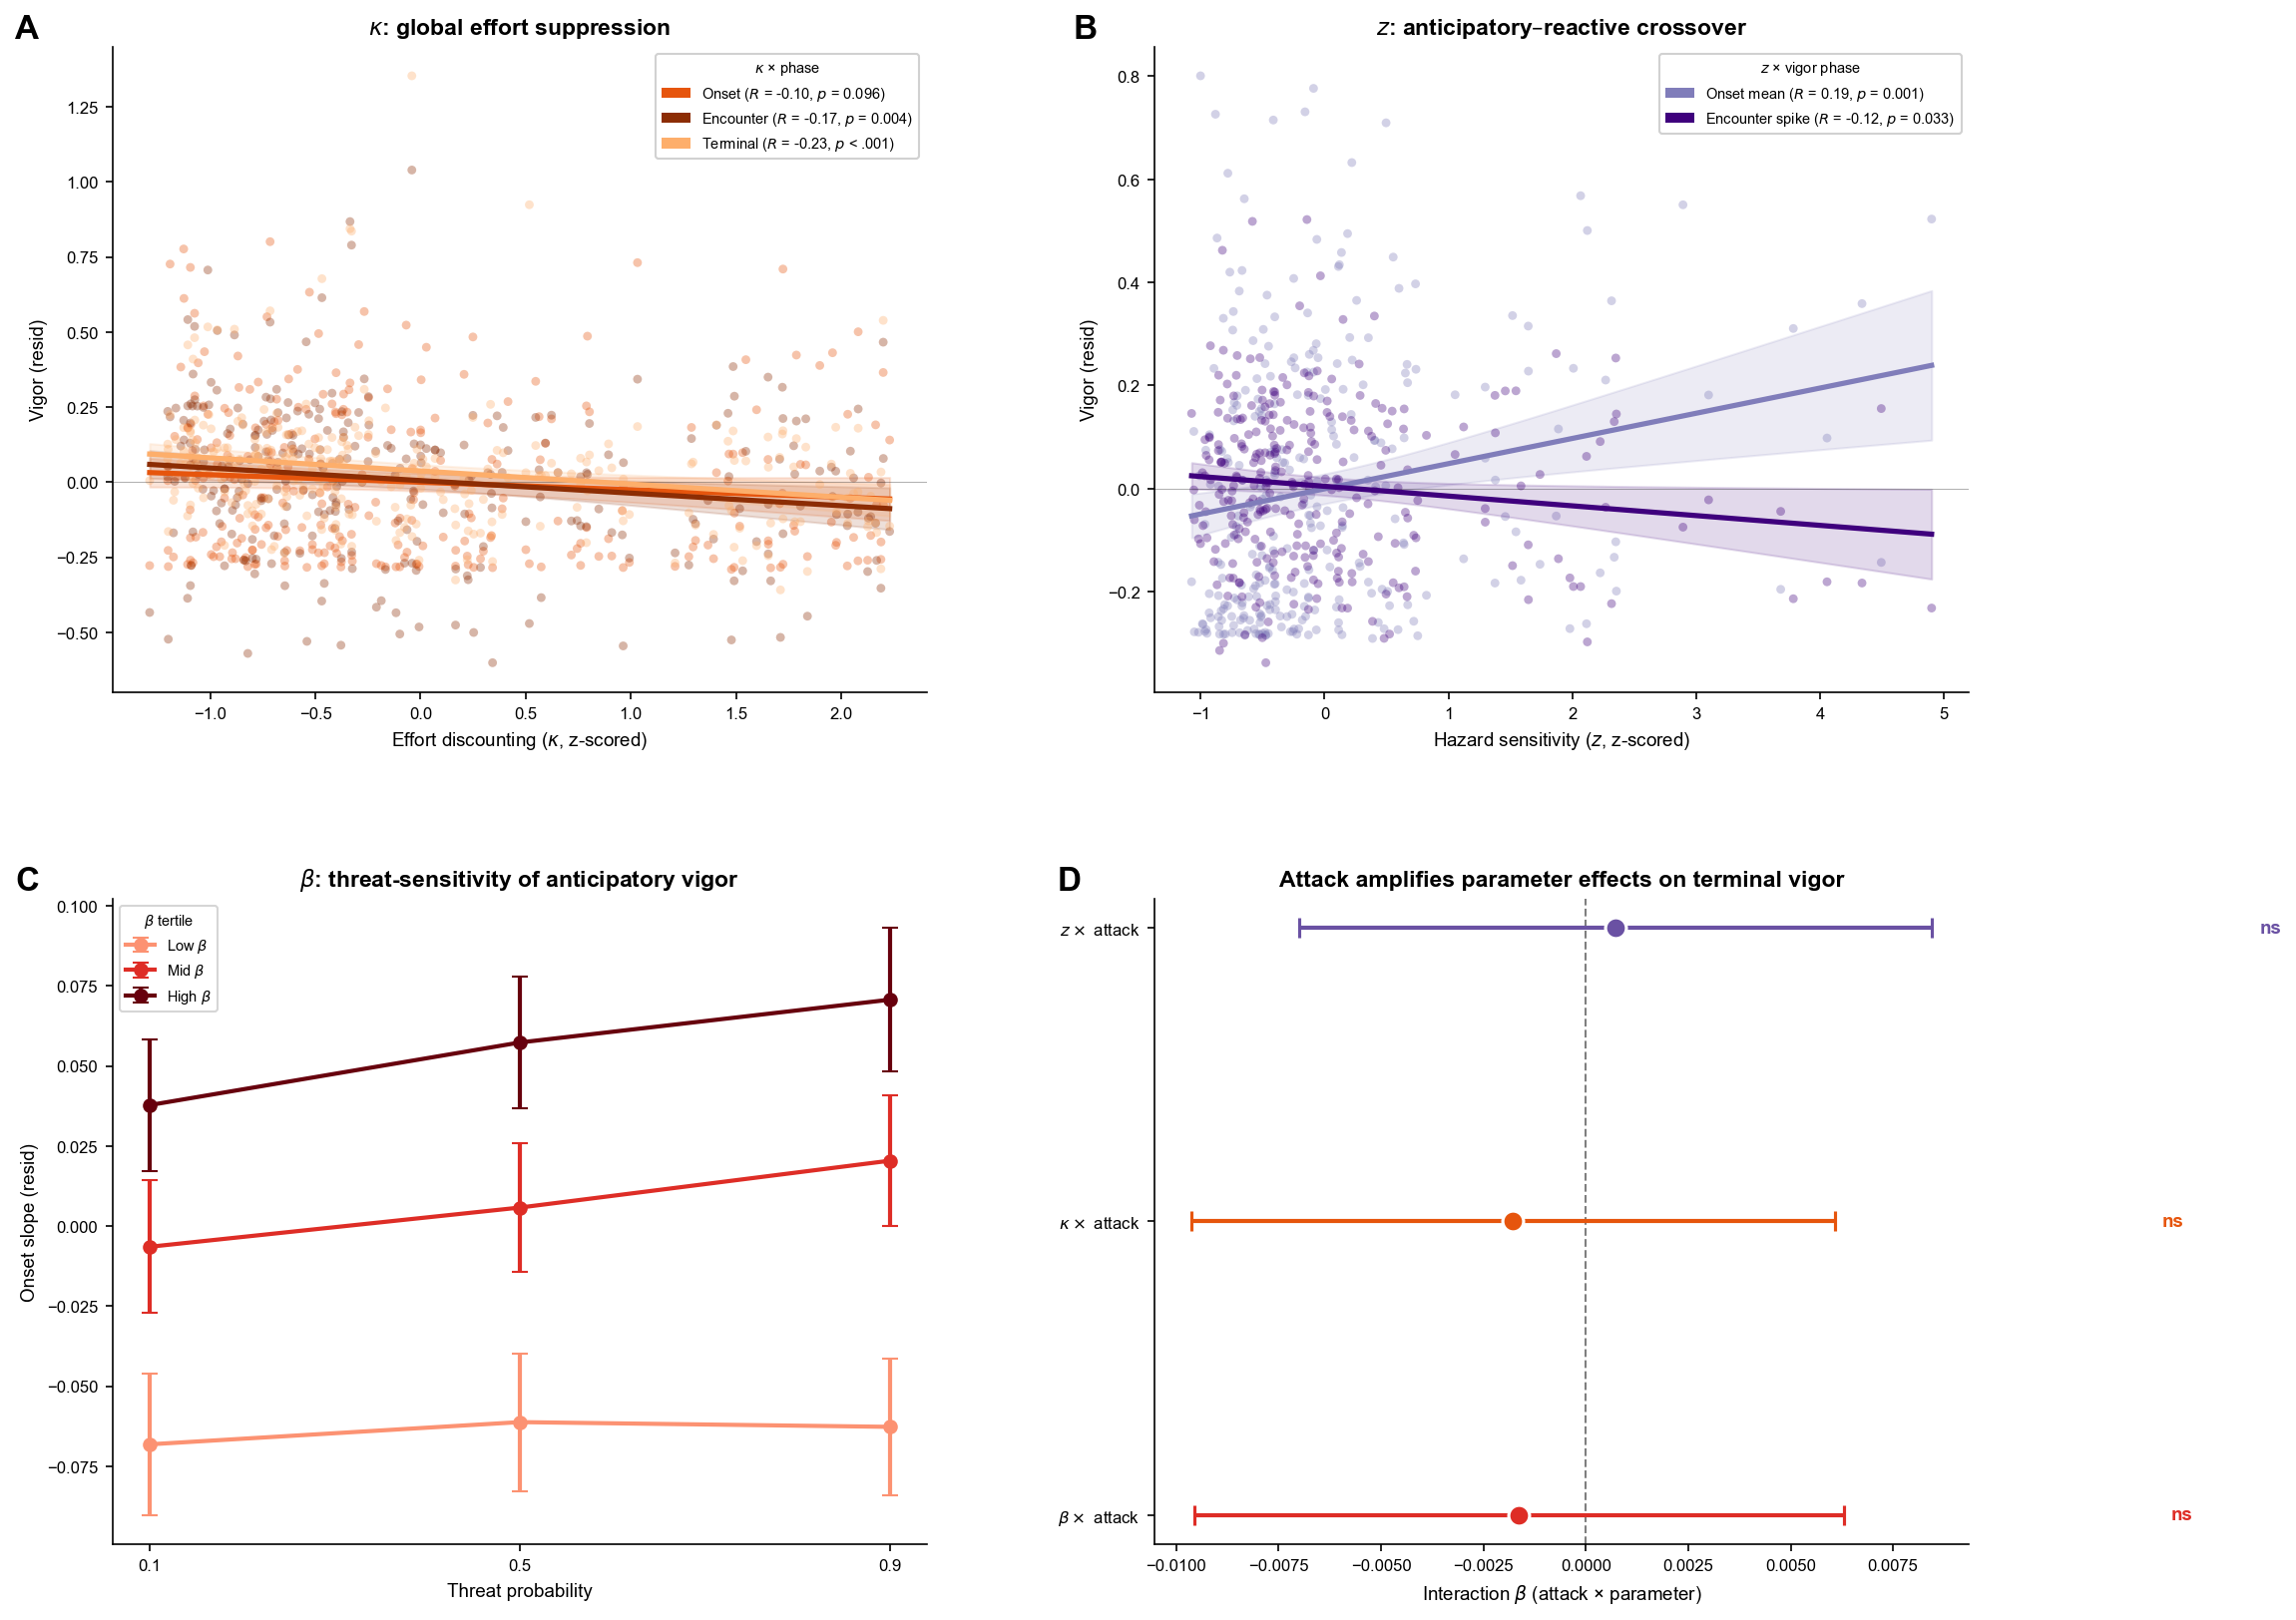

Saved → /Users/nokada/Desktop/EffortForagingUnderThreat/figs/fig2_parameter_dissociation_v5.png


In [13]:
# ── Figure 2: Computational Parameter Dissociation (scatter style) ────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import stats as sp_stats


# Style constants
PANEL_FONT = 16
TITLE_FONT = 11
LABEL_FONT = 9
TICK_FONT  = 8

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def tertile_col(df, param, new_col):
    subj_param = df.groupby('subj')[param].first()
    cuts = subj_param.quantile([1/3, 2/3])
    def _assign(v):
        if v <= cuts.iloc[0]: return 'Low'
        elif v <= cuts.iloc[1]: return 'Mid'
        else: return 'High'
    mapping = subj_param.apply(_assign)
    df[new_col] = df['subj'].map(mapping)
    return df

def scatter_with_reg(ax, x, y, color, label, alpha_dot=0.35, ms=18, zorder=2):
    """Plot scatter + regression line + CI shading."""
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    ax.scatter(x, y, c=color, alpha=alpha_dot, s=ms, edgecolors='none', zorder=zorder)

    # Regression
    slope, intercept, r, p, se = sp_stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color=color, lw=2.5, zorder=zorder + 1)

    # CI band (bootstrap-free: use prediction interval approximation)
    n = len(x)
    x_mean = x.mean()
    ss_x = np.sum((x - x_mean) ** 2)
    resid = y - (slope * x + intercept)
    mse = np.sum(resid ** 2) / (n - 2)
    se_line = np.sqrt(mse * (1/n + (x_line - x_mean)**2 / ss_x))
    t_crit = sp_stats.t.ppf(0.975, n - 2)
    ax.fill_between(x_line, y_line - t_crit * se_line, y_line + t_crit * se_line,
                    color=color, alpha=0.15, zorder=zorder)

    return r, p

def format_r_p(r, p):
    """Format correlation for legend."""
    if p < 0.001:
        return f'$R$ = {r:.2f}, $p$ < .001'
    else:
        return f'$R$ = {r:.2f}, $p$ = {p:.3f}'

def group_psth(df, time_col, value_col, group_col, t_min, t_max, dt=0.05):
    n_dec = max(0, int(np.ceil(-np.log10(dt))))
    t_grid = np.round(np.arange(t_min, t_max + dt/2, dt), n_dec)
    results = {}
    for grp, gdf in df.groupby(group_col):
        gdf = gdf.copy()
        gdf['t_bin'] = np.round(np.round(gdf[time_col] / dt) * dt, n_dec)
        gdf = gdf[(gdf['t_bin'] >= t_min) & (gdf['t_bin'] <= t_max)]
        subj_means = gdf.groupby(['subj', 't_bin'])[value_col].mean().reset_index()
        grand = subj_means.groupby('t_bin')[value_col].agg(['mean', 'sem']).reindex(t_grid)
        results[grp] = grand
    return t_grid, results

# ─────────────────────────────────────────────────────────────────────────────
# Compute subject-level means for scatter plots
# ─────────────────────────────────────────────────────────────────────────────

# DVs we need at subject level
scatter_dvs = ['onset_mean_resid', 'onset_slope_resid', 'post_encounter_vigor_resid',
               'terminal_mean_resid', 'encounter_spike_resid']

subj_df = df_trial.groupby('subj').agg(
    kappa_z=('kappa_z', 'first'),
    z_z=('z_z', 'first'),
    beta_z=('beta_z', 'first'),
    **{dv: (dv, 'mean') for dv in scatter_dvs if dv in df_trial.columns}
).reset_index()

# Also add beta tertile for Panel C
df_trial = tertile_col(df_trial, 'beta_z', 'beta_tert')

# Time series for Panel B inset
ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')
if 'z_tert' not in ts.columns:
    subj_z = df_trial.groupby('subj')['z_z'].first().reset_index()
    cuts = subj_z['z_z'].quantile([1/3, 2/3])
    subj_z['z_tert'] = subj_z['z_z'].apply(
        lambda v: 'Low' if v <= cuts.iloc[0] else ('Mid' if v <= cuts.iloc[1] else 'High'))
    ts = ts.merge(subj_z[['subj', 'z_tert']], on='subj', how='left')

# ─────────────────────────────────────────────────────────────────────────────
# Color definitions
# ─────────────────────────────────────────────────────────────────────────────

# Phase colors for Panel A (κ scatter)
phase_colors = {
    'Onset':     '#e6550d',  # warm orange
    'Encounter': '#8c2d04',  # dark brown-orange
    'Terminal':  '#fdae6b',  # light orange
}

# DV colors for Panel B (z scatter)
z_scatter_colors = {
    'Onset mean':      '#807dba',  # medium purple
    'Encounter spike': '#3f007d',  # dark purple
}

# Beta tertile colors
tert_colors_beta = {'Low': '#fc9272', 'Mid': '#de2d26', 'High': '#67000d'}
tert_order = ['Low', 'Mid', 'High']

# Forest plot colors
param_colors = {
    'kappa_z': '#e6550d',
    'z_z':     '#6a51a3',
    'beta_z':  '#de2d26',
}
param_display = {'kappa_z': '$\\kappa$', 'z_z': '$z$', 'beta_z': '$\\beta$'}

# ─────────────────────────────────────────────────────────────────────────────
# Build figure
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13), dpi=150)
gs = gridspec.GridSpec(2, 2, hspace=0.32, wspace=0.28)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — κ global brake: scatter of κ vs vigor in 3 phases
# ═══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, 0])

x_kappa = subj_df['kappa_z'].values

dv_phase_map = [
    ('onset_mean_resid',            'Onset'),
    ('post_encounter_vigor_resid',  'Encounter'),
    ('terminal_mean_resid',         'Terminal'),
]

legend_texts = []
for dv_col, phase_label in dv_phase_map:
    if dv_col not in subj_df.columns:
        continue
    y = subj_df[dv_col].values
    color = phase_colors[phase_label]
    r, p = scatter_with_reg(ax_a, x_kappa, y, color, phase_label)
    legend_texts.append(f'{phase_label} ({format_r_p(r, p)})')

# Manual legend
handles = [mpatches.Patch(facecolor=phase_colors[phase], label=txt)
           for (_, phase), txt in zip(dv_phase_map, legend_texts)]
ax_a.legend(handles=handles, fontsize=7, loc='upper right',
            title='$\\kappa$ × phase', title_fontsize=7,
            framealpha=0.9, edgecolor='#ccc')

ax_a.set_xlabel('Effort discounting ($\\kappa$, z-scored)', fontsize=LABEL_FONT)
ax_a.set_ylabel('Vigor (resid)', fontsize=LABEL_FONT)
ax_a.set_title('$\\kappa$: global effort suppression', fontsize=TITLE_FONT, fontweight='bold')
ax_a.axhline(0, color='k', lw=0.5, alpha=0.3)
ax_a.tick_params(labelsize=TICK_FONT)

ax_a.text(-0.12, 1.05, 'A', transform=ax_a.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — z crossover: scatter of z vs onset_mean and encounter_spike
# ═══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[0, 1])

x_z = subj_df['z_z'].values

z_dv_map = [
    ('onset_mean_resid',      'Onset mean'),
    ('encounter_spike_resid', 'Encounter spike'),
]

legend_texts_z = []
for dv_col, dv_label in z_dv_map:
    if dv_col not in subj_df.columns:
        continue
    y = subj_df[dv_col].values
    color = z_scatter_colors[dv_label]
    r, p = scatter_with_reg(ax_b, x_z, y, color, dv_label)
    legend_texts_z.append(f'{dv_label} ({format_r_p(r, p)})')

handles_z = [mpatches.Patch(facecolor=z_scatter_colors[lbl], label=txt)
             for (_, lbl), txt in zip(z_dv_map, legend_texts_z)]
ax_b.legend(handles=handles_z, fontsize=7, loc='upper right',
            title='$z$ × vigor phase', title_fontsize=7,
            framealpha=0.9, edgecolor='#ccc')

ax_b.set_xlabel('Hazard sensitivity ($z$, z-scored)', fontsize=LABEL_FONT)
ax_b.set_ylabel('Vigor (resid)', fontsize=LABEL_FONT)
ax_b.set_title('$z$: anticipatory–reactive crossover', fontsize=TITLE_FONT, fontweight='bold')
ax_b.axhline(0, color='k', lw=0.5, alpha=0.3)
ax_b.tick_params(labelsize=TICK_FONT)

ax_b.text(-0.10, 1.05, 'B', transform=ax_b.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL C — β × threat on onset slope
# ═══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[1, 0])

subj_means = (df_trial.groupby(['subj', 'threat', 'beta_tert'])['onset_slope_resid']
              .mean().reset_index())
grand = (subj_means.groupby(['threat', 'beta_tert'])['onset_slope_resid']
         .agg(['mean', 'sem']).reset_index())

for tert in tert_order:
    sub = grand[grand['beta_tert'] == tert]
    ax_c.errorbar(sub['threat'], sub['mean'], yerr=sub['sem'],
                  marker='o', ms=6, lw=2, capsize=4,
                  color=tert_colors_beta[tert], label=f'{tert} $\\beta$')

ax_c.set_xlabel('Threat probability', fontsize=LABEL_FONT)
ax_c.set_ylabel('Onset slope (resid)', fontsize=LABEL_FONT)
ax_c.set_title('$\\beta$: threat-sensitivity of anticipatory vigor',
               fontsize=TITLE_FONT, fontweight='bold')
ax_c.set_xticks(sorted(df_trial['threat'].unique()))
ax_c.legend(fontsize=7, title='$\\beta$ tertile', title_fontsize=7)
ax_c.tick_params(labelsize=TICK_FONT)

ax_c.text(-0.12, 1.05, 'C', transform=ax_c.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL D — Forest plot: attack × parameter on terminal AUC
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[1, 1])

interaction_params = ['attack_c:z_z', 'attack_c:kappa_z', 'attack_c:beta_z']
interaction_labels = ['$z \\times$ attack', '$\\kappa \\times$ attack', '$\\beta \\times$ attack']
forest_colors = [param_colors['z_z'], param_colors['kappa_z'], param_colors['beta_z']]

y_positions_d = np.arange(len(interaction_params))

for i, (param, label, color) in enumerate(zip(interaction_params, interaction_labels, forest_colors)):
    row = fdr_df[(fdr_df['dv_base'] == 'terminal_auc') & (fdr_df['predictor'] == param)]
    if len(row) > 0:
        row = row.iloc[0]
        beta = row['beta']
        ci_lo = row['ci_lo']
        ci_hi = row['ci_hi']

        ax_d.errorbar(beta, i, xerr=[[beta - ci_lo], [ci_hi - beta]],
                      fmt='o', ms=10, color=color, capsize=5, capthick=2,
                      elinewidth=2, markeredgecolor='white', markeredgewidth=1.5,
                      zorder=3)

        if row['p_fdr'] < 0.001:
            sig_str = '***'
        elif row['p_fdr'] < 0.01:
            sig_str = '**'
        elif row['p_fdr'] < 0.05:
            sig_str = '*'
        else:
            sig_str = 'ns'

        ax_d.text(ci_hi + 0.008, i, sig_str, va='center', fontsize=9,
                  fontweight='bold', color=color)

ax_d.axvline(0, color='k', ls='--', lw=1, alpha=0.5, zorder=1)
ax_d.set_yticks(y_positions_d)
ax_d.set_yticklabels(interaction_labels, fontsize=LABEL_FONT)
ax_d.set_xlabel('Interaction $\\beta$ (attack × parameter)', fontsize=LABEL_FONT)
ax_d.set_title('Attack amplifies parameter effects on terminal vigor',
               fontsize=TITLE_FONT, fontweight='bold')
ax_d.tick_params(labelsize=TICK_FONT)
ax_d.invert_yaxis()

ax_d.text(-0.12, 1.05, 'D', transform=ax_d.transAxes,
          fontsize=PANEL_FONT, fontweight='bold', va='top')

# ── Save ──
fig.savefig(FIGS_DIR / 'fig2_parameter_dissociation_v5.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FIGS_DIR / "fig2_parameter_dissociation_v5.png"}')

---
## Supplementary: vigor_norm Convergence Check

Repeat the same 39-test extraction from the **norm** stream to assess which effects converge across normalization approaches.

---
## Summary & Manuscript Text

Collect all claim evaluations and generate copy-pasteable manuscript text.

In [14]:
# ── Summary of all claims ─────────────────────────────────────────────────

def fmt_beta(row):
    return f'\u03B2 = {row["beta"]:.3f}, SE = {row["se"]:.3f}, q = {row["p_fdr"]:.3f}'

print('=' * 70)
print('MANUSCRIPT TEXT HELPERS')
print('=' * 70)

# 2A
print('\n--- 2A: \u03BA global constraint ---')
for dv_base in claim_2a_dvs:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'kappa_z')].iloc[0]
    print(f'  {dv_base}: {fmt_beta(row)}')

# 2B
print('\n--- 2B: z crossover ---')
for dv_base, label in [('onset_mean', 'onset level'), ('onset_slope', 'onset ramp'), ('encounter_spike', 'spike')]:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'z_z')].iloc[0]
    print(f'  z on {label} ({dv_base}): {fmt_beta(row)}')

# 2C
print('\n--- 2C: \u03B2\u00d7threat onset-specificity ---')
for dv_base in ONSET_DVS + ENCOUNTER_TERMINAL_DVS:
    row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == 'beta_z:threat_c')].iloc[0]
    tag = '\u2713' if row['sig_fdr'] else ' '
    print(f'  {tag} {dv_base}: {fmt_beta(row)}')

# 2D
print('\n--- 2D: attack\u00d7param on terminal_auc ---')
for param in PARAMS:
    pred_name = f'attack_c:{param}'
    row = fdr_df[(fdr_df['dv_base'] == 'terminal_auc') & (fdr_df['predictor'] == pred_name)].iloc[0]
    print(f'  {pred_name}: {fmt_beta(row)}')

MANUSCRIPT TEXT HELPERS

--- 2A: κ global constraint ---
  onset_slope: β = -0.046, SE = 0.012, q = 0.002
  post_encounter_vigor: β = -0.049, SE = 0.014, q = 0.004
  terminal_mean: β = -0.044, SE = 0.011, q = 0.002

--- 2B: z crossover ---
  z on onset level (onset_mean): β = 0.055, SE = 0.015, q = 0.002
  z on onset ramp (onset_slope): β = 0.028, SE = 0.012, q = 0.076
  z on spike (encounter_spike): β = -0.021, SE = 0.009, q = 0.063

--- 2C: β×threat onset-specificity ---
    onset_slope: β = 0.007, SE = 0.004, q = 0.240
    onset_mean: β = 0.006, SE = 0.003, q = 0.103
    onset_peak: β = 0.006, SE = 0.003, q = 0.103
    encounter_spike: β = 0.008, SE = 0.010, q = 0.568
    post_encounter_vigor: β = 0.011, SE = 0.009, q = 0.378
    terminal_mean: β = 0.011, SE = 0.007, q = 0.238

--- 2D: attack×param on terminal_auc ---
  attack_c:z_z: β = 0.001, SE = 0.004, q = 0.880
  attack_c:kappa_z: β = -0.002, SE = 0.004, q = 0.801
  attack_c:beta_z: β = -0.002, SE = 0.004, q = 0.807


---
## Export: CSV and LaTeX

In [15]:
# ── Export CSV and LaTeX ───────────────────────────────────────────────────

from IPython.display import display, HTML

# ═══ CSV ═══
csv_out = fdr_df.copy()
csv_out['sig_star'] = csv_out['p_fdr'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))
csv_out.to_csv(TABLES / 'table_s2_parameter_dissociation.csv', index=False)
print(f'CSV  saved \u2192 {TABLES / "table_s2_parameter_dissociation.csv"}')

# Also save the stream comparison
if "comparison" in dir():
    comparison.to_csv(TABLES / 'table_s2_stream_comparison.csv', index=False)
print(f'CSV  saved \u2192 {TABLES / "table_s2_stream_comparison.csv"}')

# ═══ LaTeX ═══

def tex_esc(s):
    return s.replace('_', r'\_').replace('&', r'\&').replace('%', r'\%').replace('#', r'\#')

def tex_p(p):
    if p < 0.001: return r'$<$.001'
    return f'{p:.3f}'

def tex_sig(p):
    if p < 0.001: return r'$^{***}$'
    if p < 0.01:  return r'$^{**}$'
    if p < 0.05:  return r'$^{*}$'
    return ''

def tex_ci(lo, hi):
    return f'[{lo:.3f}, {hi:.3f}]'

# Group structure for the table
sections = [
    ('2A: $\\kappa$ global constraint', [
        ('onset_slope', 'kappa_z', 'main'),
        ('post_encounter_vigor', 'kappa_z', 'main'),
        ('terminal_mean', 'kappa_z', 'main'),
    ]),
    ('2B: $z$ preparatory allocation', [
        ('onset_mean', 'z_z', 'main'),
        ('onset_slope', 'z_z', 'main'),
        ('encounter_spike', 'z_z', 'main'),
    ]),
    ('2C: $\\beta \\times$ threat on onset', [
        ('onset_slope', 'beta_z:threat_c', 'param\u00d7threat'),
        ('onset_peak', 'beta_z:threat_c', 'param\u00d7threat'),
        ('onset_mean', 'beta_z:threat_c', 'param\u00d7threat'),
        ('encounter_spike', 'beta_z:threat_c', 'param\u00d7threat'),
        ('post_encounter_vigor', 'beta_z:threat_c', 'param\u00d7threat'),
        ('terminal_mean', 'beta_z:threat_c', 'param\u00d7threat'),
    ]),
    ('2D: Attack $\\times$ parameter on terminal AUC', [
        ('terminal_auc', 'attack_c:z_z', 'attack\u00d7param'),
        ('terminal_auc', 'attack_c:kappa_z', 'attack\u00d7param'),
        ('terminal_auc', 'attack_c:beta_z', 'attack\u00d7param'),
    ]),
]

lines = []
lines.append(r'\begin{table}[htbp]')
lines.append(r'\centering')
lines.append(r'\caption{Computational parameter dissociation (Step 2). All models are linear mixed models (REML, LBFGS) with random intercept per subject. Primary stream: demand-residualized vigor. $p_\text{FDR}$ corrected across 39 tests (Benjamini--Hochberg).}')
lines.append(r'\label{tab:s2_dissociation}')
lines.append(r'\footnotesize')
lines.append(r'\begin{tabular}{@{}llrcclcrr@{}}')
lines.append(r'\toprule')
lines.append(r'DV & Predictor & $\beta$ & SE & 95\% CI & $p$ & $p_\text{FDR}$ & & $N$ \\')
lines.append(r'\midrule')

for sec_i, (sec_title, sec_rows) in enumerate(sections):
    if sec_i > 0:
        lines.append(r'\addlinespace[4pt]')
    lines.append(f'\\multicolumn{{9}}{{@{{}}l}}{{\\textbf{{{sec_title}}}}} \\\\')
    lines.append(r'\addlinespace[2pt]')
    
    for dv_base, predictor, test_type in sec_rows:
        row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == predictor)].iloc[0]
        
        dv_tex = tex_esc(dv_base)
        pred_tex = tex_esc(predictor)
        beta_tex = f'{row["beta"]:.3f}'
        se_tex = f'{row["se"]:.3f}'
        ci_tex = tex_ci(row['ci_lo'], row['ci_hi'])
        p_tex = tex_p(row['p'])
        pfdr_tex = tex_p(row['p_fdr'])
        sig_tex = tex_sig(row['p_fdr'])
        n_tex = f'{int(row["nobs"]):,}'
        
        lines.append(
            f'  {dv_tex} & {pred_tex} & {beta_tex} & {se_tex} & '
            f'{ci_tex} & {p_tex} & {pfdr_tex} & {sig_tex} & {n_tex} \\\\'
        )

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\vspace{4pt}')
lines.append(r'\raggedright')
lines.append(r'\scriptsize')
lines.append(r'\textit{Note.} $^{***}p_\text{FDR} < .001$; $^{**}p_\text{FDR} < .01$; $^{*}p_\text{FDR} < .05$. ')
lines.append(r'Onset models: DV $\sim$ z\_z $\times$ threat\_c + kappa\_z $\times$ threat\_c + beta\_z $\times$ threat\_c + C(choice) + (1$|$subj). ')
lines.append(r'Encounter/terminal models add: attack\_c + attack\_c:z\_z + attack\_c:kappa\_z + attack\_c:beta\_z. ')
lines.append(r'FDR family = 39 tests (18 main effects + 18 param$\times$threat + 3 attack$\times$param).')
lines.append(r'\end{table}')

tex_str = '\n'.join(lines)

tex_out = TABLES / 'table_s2_parameter_dissociation.tex'
with open(tex_out, 'w') as f:
    f.write(tex_str)

print(f'LaTeX saved \u2192 {tex_out}')
print()
print('Preview:')
print('\u2500' * 80)
print(tex_str)

CSV  saved → /Users/nokada/Desktop/EffortForagingUnderThreat/results/tables/table_s2_parameter_dissociation.csv
CSV  saved → /Users/nokada/Desktop/EffortForagingUnderThreat/results/tables/table_s2_stream_comparison.csv
LaTeX saved → /Users/nokada/Desktop/EffortForagingUnderThreat/results/tables/table_s2_parameter_dissociation.tex

Preview:
────────────────────────────────────────────────────────────────────────────────
\begin{table}[htbp]
\centering
\caption{Computational parameter dissociation (Step 2). All models are linear mixed models (REML, LBFGS) with random intercept per subject. Primary stream: demand-residualized vigor. $p_\text{FDR}$ corrected across 39 tests (Benjamini--Hochberg).}
\label{tab:s2_dissociation}
\footnotesize
\begin{tabular}{@{}llrcclcrr@{}}
\toprule
DV & Predictor & $\beta$ & SE & 95\% CI & $p$ & $p_\text{FDR}$ & & $N$ \\
\midrule
\multicolumn{9}{@{}l}{\textbf{2A: $\kappa$ global constraint}} \\
\addlinespace[2pt]
  onset\_slope & kappa\_z & -0.046 & 0.012 & [

In [16]:
# ── HTML display of key results ───────────────────────────────────────────

html = """
<style>
    .s2-table { border-collapse: collapse; font-size: 11px; font-family: 'Helvetica', sans-serif; }
    .s2-table th { background: #2c3e50; color: white; padding: 6px 10px; text-align: left;
                   font-weight: 600; border-bottom: 2px solid #1a252f; }
    .s2-table td { padding: 5px 10px; border-bottom: 1px solid #e0e0e0; vertical-align: top; }
    .s2-table tr:hover { background: #f5f5f5; }
    .s2-table .group-header { background: #ecf0f1; font-weight: 700; font-size: 11px; }
    .s2-table .sig { color: #c0392b; font-weight: 700; }
    .s2-table .ns { color: #95a5a6; }
</style>
<table class="s2-table">
<thead>
    <tr>
        <th>DV</th>
        <th>Predictor</th>
        <th style="text-align:right">&beta;</th>
        <th style="text-align:right">SE</th>
        <th>95% CI</th>
        <th style="text-align:right"><i>p</i></th>
        <th style="text-align:right"><i>p</i><sub>FDR</sub></th>
        <th></th>
        <th style="text-align:right">N</th>
    </tr>
</thead>
<tbody>
"""

html_sections = [
    ('2A \u2014 \u03ba global constraint', [
        ('onset_slope', 'kappa_z'),
        ('post_encounter_vigor', 'kappa_z'),
        ('terminal_mean', 'kappa_z'),
    ]),
    ('2B \u2014 z preparatory allocation', [
        ('onset_mean', 'z_z'),
        ('onset_slope', 'z_z'),
        ('encounter_spike', 'z_z'),
    ]),
    ('2C \u2014 \u03b2\u00d7threat onset-specificity', [
        ('onset_slope', 'beta_z:threat_c'),
        ('onset_peak', 'beta_z:threat_c'),
        ('onset_mean', 'beta_z:threat_c'),
        ('encounter_spike', 'beta_z:threat_c'),
        ('post_encounter_vigor', 'beta_z:threat_c'),
        ('terminal_mean', 'beta_z:threat_c'),
    ]),
    ('2D \u2014 Attack\u00d7param on terminal AUC', [
        ('terminal_auc', 'attack_c:z_z'),
        ('terminal_auc', 'attack_c:kappa_z'),
        ('terminal_auc', 'attack_c:beta_z'),
    ]),
]

def html_p(p):
    return '&lt; .001' if p < 0.001 else f'{p:.3f}'

def html_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

for sec_title, sec_items in html_sections:
    html += f'<tr class="group-header"><td colspan="9">{sec_title}</td></tr>\n'
    for dv_base, predictor in sec_items:
        row = fdr_df[(fdr_df['dv_base'] == dv_base) & (fdr_df['predictor'] == predictor)].iloc[0]
        sig_cls = 'sig' if row['sig_fdr'] else 'ns'
        html += f"""<tr>
    <td>{dv_base}</td>
    <td>{predictor}</td>
    <td style="text-align:right"><b>{row['beta']:.3f}</b></td>
    <td style="text-align:right">{row['se']:.3f}</td>
    <td>[{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]</td>
    <td style="text-align:right">{html_p(row['p'])}</td>
    <td style="text-align:right" class="{sig_cls}">{html_p(row['p_fdr'])}</td>
    <td class="sig">{html_sig(row['p_fdr'])}</td>
    <td style="text-align:right">{int(row['nobs']):,}</td>
</tr>\n"""

html += """</tbody></table>
<p style="font-size:10px; color:#777;">
<em>Note.</em> ***p<sub>FDR</sub> &lt; .001; **p<sub>FDR</sub> &lt; .01; *p<sub>FDR</sub> &lt; .05. 
FDR family = 39 tests. Primary stream: demand-residualized vigor.
</p>"""

display(HTML(html))